# SARIMAX + LSTM 

In [1]:
# ============================================================
import numpy as np
import pandas as pd

from afg_puc import config
import random
import scipy.stats as stats
import matplotlib.pyplot as plt

from typing import List, Optional, Dict, Tuple
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import acorr_ljungbox 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import copy
import time
from itertools import product
from typing import Dict, List, Tuple, Optional 
from statsmodels.tsa.stattools import grangercausalitytests

2025-12-27 00:59:03.394 | INFO     | afg_puc.config:<module>:12 - PROJ_ROOT path is: C:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc


C:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc


## DATA

In [ ]:
df_consol = pd.read_parquet(config.PROCESSED_DATA_DIR / "df_consol.parquet", engine="pyarrow")
df_consol.index = pd.to_datetime(df_consol.index)
dow = df_consol.index.weekday
df_consol["cercania_lunes"] = (0 - dow) % 7
df_consol["lejanania_lunes_pas"] = (dow - 0) % 7
df_consol["mes"] = df_consol.index.month
df_consol["quincena"] = np.where(df_consol.index.day <= 15, 1, 2)
next_month = df_consol.index.to_series().shift(-1).dt.month
df_consol["cierre"] = (next_month != df_consol.index.month).astype(int)

# ---- Split test diario (63 días) ----
TEST_DAYS = 63
df_consol = df_consol.sort_index()
df_consol_train = df_consol.iloc[:-TEST_DAYS].copy()
df_consol_test  = df_consol.iloc[-TEST_DAYS:].copy()

TARGET_COLS = ["oro", "plata", "cobre", "petroleo_brent", "gas_natural"]

## SARIMAX: clases/funciones (reutilizables)

In [ ]:
# -------------------------
# Métricas 
# -------------------------
def mape(y, yhat, eps=1e-9) -> float:
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    denom = np.maximum(np.abs(y), eps)
    return float(np.mean(np.abs((y - yhat) / denom)) * 100.0)

def rmse(y, yhat) -> float:
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))


_mape = mape
_rmse = rmse

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)

def _ensure_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        for col in ["FECHA", "fecha", "Date", "date"]:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors="coerce")
                df = df.dropna(subset=[col]).set_index(col)
                break
    df = df.sort_index()
    if isinstance(df.index, pd.DatetimeIndex):
        df = df[~df.index.duplicated(keep="last")].sort_index()
    return df

def _numeric_cols(df: pd.DataFrame) -> List[str]:
    return [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

def _safe_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.replace([np.inf, -np.inf], np.nan)
    return out

# -------------------------
# Selección de exógenas 
# -------------------------
MAX_EXOG: Optional[int] = None  # None = sin límite
COLLIN_CORR_TH = 0.90
USE_VIF_PRUNE  = True
VIF_TH         = 10.0
_EXOG_SELECTION_CACHE: Dict[tuple, List[str]] = {}

def _prune_collinearity_by_corr_ranked(
    df: pd.DataFrame, candidates: List[str], corr_abs: pd.Series, th: float
) -> List[str]:
    keep = []
    for c in candidates:
        ok = True
        for k in keep:
            cc = df[[c, k]].corr().iloc[0, 1]
            if pd.notna(cc) and abs(cc) >= th:
                ok = False
                break
        if ok:
            keep.append(c)
    return keep

def _prune_by_vif(df: pd.DataFrame, cols: List[str], th: float) -> List[str]:
    cols = cols[:]
    if len(cols) <= 1:
        return cols
    # iterativo: elimina el mayor VIF hasta que todos estén bajo th
    while True:
        X = df[cols].dropna().astype(float)
        if len(X) < 10 or X.shape[1] <= 1:
            return cols
        vifs = []
        for i in range(X.shape[1]):
            try:
                vifs.append(variance_inflation_factor(X.values, i))
            except Exception:
                vifs.append(np.inf)
        vmax = float(np.max(vifs))
        if vmax <= th:
            return cols
        drop_idx = int(np.argmax(vifs))
        cols.pop(drop_idx)
        if len(cols) <= 1:
            return cols

def _select_exog_cols(df_train: pd.DataFrame, target_col: str, max_exog: Optional[int]) -> List[str]:
    # (1) ranking por |corr|
    num_cols = _numeric_cols(df_train)
    candidates = [c for c in num_cols if c != target_col]
    candidates = [c for c in candidates if df_train[c].nunique(dropna=True) > 1]
    if not candidates:
        return []

    idx0, idx1 = df_train.index.min(), df_train.index.max()
    key = (
        target_col, idx0, idx1, len(df_train),
        tuple(candidates), max_exog,
        COLLIN_CORR_TH, USE_VIF_PRUNE, VIF_TH
    )
    if key in _EXOG_SELECTION_CACHE:
        return _EXOG_SELECTION_CACHE[key][:]

    tmp = _safe_df(df_train[[target_col] + candidates]).dropna()
    if len(tmp) < 10:
        corr_abs = pd.Series({c: 0.0 for c in candidates})
    else:
        corr_abs = tmp[candidates].corrwith(tmp[target_col]).abs().fillna(0.0)

    ranked = corr_abs.sort_values(ascending=False).index.tolist()

    # (2) poda colinealidad
    if len(tmp) >= 10:
        ranked = _prune_collinearity_by_corr_ranked(tmp, ranked, corr_abs, COLLIN_CORR_TH)

    # (3) poda VIF
    if USE_VIF_PRUNE and len(tmp) >= 10 and len(ranked) > 1:
        ranked = _prune_by_vif(tmp, ranked, VIF_TH)

    # (4) cap
    if max_exog is not None:
        ranked = ranked[: int(max_exog)]

    _EXOG_SELECTION_CACHE[key] = ranked[:]
    return ranked

def _select_exog_cols_fallback(df_train: pd.DataFrame, target_col: str, max_exog: Optional[int]=None) -> List[str]:
    cols = [c for c in _numeric_cols(df_train) if c != target_col]
    if max_exog is not None:
        cols = cols[: int(max_exog)]
    return cols

def _get_exog_cols(df_train: pd.DataFrame, target_col: str) -> List[str]:
    max_exog = globals().get("MAX_EXOG", None)
    return _select_exog_cols(df_train, target_col, max_exog) if "_select_exog_cols" in globals() else _select_exog_cols_fallback(df_train, target_col, max_exog=max_exog)

# -------------------------
# Transformaciones 
# -------------------------
def _transform_with_fixed_lambda(y, transform_type: Optional[str], lmbda: float, shift: float = 0.0):
    tt = (transform_type or "none").lower()
    y = np.asarray(y, dtype=float)

    if tt in ("none", None):
        return y

    if tt == "log":
        return np.log(np.maximum(y, 1e-12))

    if tt == "boxcox":
        # necesita y > 0 (por eso shift si hace falta)
        y_pos = y + shift
        y_pos = np.maximum(y_pos, 1e-12)
        return stats.boxcox(y_pos, lmbda=lmbda)

    if tt == "yeojohnson":
        return stats.yeojohnson(y, lmbda=lmbda)

    raise ValueError(f"transform_type no soportado: {transform_type}")

def _inv_transform_with_shift(y_t, transform_type: Optional[str], lmbda: float, shift: float = 0.0):
    tt = (transform_type or "none").lower()
    y_t = np.asarray(y_t, dtype=float)

    if tt in ("none", None):
        return y_t

    if tt == "log":
        return np.exp(y_t)

    if tt == "boxcox":
        if abs(lmbda) < 1e-10:
            out = np.exp(y_t)
        else:
            out = np.power(y_t * lmbda + 1.0, 1.0 / lmbda)
        out = out - shift
        return out

    if tt == "yeojohnson":
        # Inversa manual
        x = np.zeros_like(y_t, dtype=float)
        pos = y_t >= 0
        if abs(lmbda) < 1e-10:
            x[pos] = np.expm1(y_t[pos])
        else:
            x[pos] = np.power(y_t[pos] * lmbda + 1.0, 1.0 / lmbda) - 1.0

        neg = ~pos
        if abs(lmbda - 2.0) < 1e-10:
            x[neg] = 1.0 - np.exp(-y_t[neg])
        else:
            x[neg] = 1.0 - np.power(1.0 - y_t[neg] * (2.0 - lmbda), 1.0 / (2.0 - lmbda))
        return x

    raise ValueError(f"transform_type no soportado: {transform_type}")

def _fit_lambda_from_train(y_train, transform_type: Optional[str]):
    tt = (transform_type or "none").lower()
    y = np.asarray(pd.Series(y_train).dropna().values, dtype=float)

    if tt in ("none", None):
        return None, 0.0

    if tt == "yeojohnson":
        _, lmbda = stats.yeojohnson(y)
        return float(lmbda), 0.0

    if tt == "boxcox":
        miny = float(np.min(y)) if len(y) else 0.0
        shift = 0.0
        if miny <= 0:
            shift = (-miny) + 1e-6
        y_pos = np.maximum(y + shift, 1e-12)
        _, lmbda = stats.boxcox(y_pos)
        return float(lmbda), float(shift)

    if tt == "log":
        return None, 0.0

    raise ValueError(f"transform_type no soportado: {transform_type}")

# -------------------------
# Imputación exógenas (sin leakage)
# -------------------------
def _prep_exog_history(df_hist: pd.DataFrame, exog_cols: List[str], df_train_base: pd.DataFrame):
    if len(exog_cols) == 0:
        return None

    X = (
        df_hist.reindex(columns=exog_cols)
              .replace([np.inf, -np.inf], np.nan)
              .ffill()
    )
    med = (
        df_train_base.reindex(columns=exog_cols)
                     .replace([np.inf, -np.inf], np.nan)
                     .median(numeric_only=True)
    )
    X = X.fillna(med)
    return X

def ljung_box_pvalue(resid, lags=10) -> float:
    try:
        p = acorr_ljungbox(pd.Series(resid).dropna(), lags=[lags], return_df=True)["lb_pvalue"].iloc[0]
        return float(p)
    except Exception:
        return np.nan

# -------------------------
# Ljung-Box SAFE (para ventanas cortas)
# -------------------------
def ljung_box_pvalue_safe(resid, lag: int = 7) -> Tuple[float, int]:
    """
    Devuelve (pvalue, lag_used). Si no hay suficientes observaciones, retorna (nan, lag_used).
    Regla statsmodels: se necesita n_obs > lag.
    """
    r = pd.Series(resid).dropna().astype(float).values
    n = len(r)
    if n <= 2:
        return (np.nan, 0)
    lag_used = int(min(lag, n - 1))
    if lag_used < 1:
        return (np.nan, lag_used)
    try:
        p = acorr_ljungbox(pd.Series(r), lags=[lag_used], return_df=True)["lb_pvalue"].iloc[0]
        return (float(p), lag_used)
    except Exception:
        return (np.nan, lag_used)

# -------------------------
# Reporte SOLO exógenas usadas por el modelo + pvalues Granger por lag
# -------------------------
def sarimax_exog_used_granger_report(
    asset: str,
    df_train: pd.DataFrame,
    cfg: dict,
    max_exog: Optional[int] = None,
    maxlag: int = 10,
    alpha: float = 0.05,
    test_name: str = "ssr_ftest",
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Reporte de exógenas:
    - SOLO considera las exógenas que efectivamente usa el modelo (_get_exog_cols con df_train).
    - Ranking = orden retornado por _get_exog_cols (tu pipeline).
    - Para cada exógena, muestra p-value por lag (1..maxlag) del test Granger X -> Y.
    - significant_any=True si existe al menos 1 lag con p<alpha.
    """
    df_train = _ensure_datetime_index(df_train)
    if asset not in df_train.columns:
        raise ValueError(f"'{asset}' no está en df_train.columns")

    # asegurar mismo cap de exógenas
    old_max = globals().get("MAX_EXOG", None)
    if max_exog is not None:
        globals()["MAX_EXOG"] = max_exog
    exog_cols_used = _get_exog_cols(df_train, asset)
    globals()["MAX_EXOG"] = old_max

    y = df_train[asset].astype(float)

    rows = []
    for i, xcol in enumerate(exog_cols_used, start=1):
        if xcol not in df_train.columns:
            continue

        x = df_train[xcol].astype(float)
        df_xy = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()

        # default
        pvals_by_lag = {lag: np.nan for lag in range(1, maxlag + 1)}
        sig_lags = []
        min_p = np.nan
        best_lag = np.nan
        sig_any = False

        if len(df_xy) >= (maxlag + 5):
            try:
                res = grangercausalitytests(df_xy[["y", "x"]], maxlag=maxlag, verbose=False)
                for lag in range(1, maxlag + 1):
                    if test_name in res[lag][0]:
                        pvals_by_lag[lag] = float(res[lag][0][test_name][1])
                valid = {lag: pv for lag, pv in pvals_by_lag.items() if np.isfinite(pv)}
                if valid:
                    best_lag = min(valid, key=lambda k: valid[k])
                    min_p = valid[best_lag]
                    sig_lags = [lag for lag, pv in valid.items() if pv < alpha]
                    sig_any = len(sig_lags) > 0
            except Exception:
                pass

        row = {
            "asset": asset,
            "exog": xcol,
            "rank_used": i,
            "significant_any": bool(sig_any),
            "min_pvalue": float(min_p) if np.isfinite(min_p) else np.nan,
            "best_lag": int(best_lag) if np.isfinite(best_lag) else np.nan,
            "significant_lags": sig_lags,
            "n_obs": int(len(df_xy)),
        }
        # columnas p_lag1..p_lag10
        for lag in range(1, maxlag + 1):
            row[f"p_lag{lag}"] = pvals_by_lag.get(lag, np.nan)

        rows.append(row)

    df_rep = pd.DataFrame(rows)
    if not df_rep.empty:
        # ranking alternativo por min_pvalue (solo para mirar)
        df_rep["rank_by_min_p"] = (
            df_rep["min_pvalue"].fillna(np.inf).rank(method="dense").astype(int)
        )
        # ordenar por el ranking real de uso
        df_rep = df_rep.sort_values(["rank_used"])

    return df_rep, exog_cols_used

## SARIMAX

In [ ]:
# ============================================================
# SARIMAX: EVALUACIÓN  (TEST) + RUNNER
# ============================================================
def evaluate_sarimax_rolling(
    asset_name: str,
    sarimax_cfg: dict,
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    window_size: int = 7,
    n_windows: int = 9,
    save_globals: bool = True,
    ljung_lag: int = 7,
    ljung_alpha: float = 0.05,
):
    df_train = _ensure_datetime_index(df_train)
    df_test  = _ensure_datetime_index(df_test)

    if asset_name not in df_train.columns:
        raise ValueError(f"'{asset_name}' no está en df_train.columns")
    if asset_name not in df_test.columns:
        raise ValueError(f"'{asset_name}' no está en df_test.columns")

    order = tuple(sarimax_cfg["order"])
    seasonal_order = tuple(sarimax_cfg["seasonal_order"])
    transform_type = sarimax_cfg.get("transform", None)

    # Exógenas SOLO desde train (pipeline)
    exog_cols = _get_exog_cols(df_train, asset_name)

    # por robustez: asegurar que existan en df_test
    if len(exog_cols) > 0:
        missing = [c for c in exog_cols if c not in df_test.columns]
        if missing:
            print(f"[WARN] {asset_name}: exógenas faltantes en df_test, se eliminan: {missing}")
            exog_cols = [c for c in exog_cols if c in df_test.columns]

    # 63 días = 9 ventanas * 7 días (por defecto)
    K = min(len(df_test), int(window_size) * int(n_windows))
    w_used = K // int(window_size)
    if w_used < 1:
        raise ValueError("df_test no tiene suficientes puntos para al menos 1 ventana completa.")
    df_test_eval = df_test.iloc[: w_used * int(window_size)].copy()

    # Transformación: lambda/shift SOLO con train
    lmbda, shift = _fit_lambda_from_train(df_train[asset_name].values, transform_type)

    preds_all = []
    window_ids = []
    step_in_window = []
    rows_windows = []

    # === Rolling por ventanas ===
    for w in range(w_used):
        a = w * int(window_size)
        b = (w + 1) * int(window_size)
        df_test_w = df_test_eval.iloc[a:b]

        # Expanding entre ventanas: train + pasado observado (hasta a)
        df_train_w = pd.concat([df_train, df_test_eval.iloc[:a]], axis=0)
        df_train_w = df_train_w[~df_train_w.index.duplicated(keep="last")].sort_index()

        # --- WALK-FORWARD 1-step dentro de la ventana ---
        df_hist_target = df_train_w[[asset_name]].copy()

        if len(exog_cols) > 0:
            df_hist_exog = df_train_w[exog_cols].copy()
        else:
            df_hist_exog = pd.DataFrame(index=df_hist_target.index)

        fc_window = []

        for t in range(len(df_test_w)):
            # y hist transformada
            y_hist_orig = df_hist_target[asset_name].astype(float).values
            y_hist_t = _transform_with_fixed_lambda(y_hist_orig, transform_type, lmbda, shift=shift)
            y_hist_t = pd.Series(y_hist_t, index=df_hist_target.index)

            # X hist: SOLO exógenas conocidas a la fecha (ffill) + mediana de train
            if len(exog_cols) > 0:
                df_hist_combined = pd.concat([df_hist_target, df_hist_exog], axis=1)
                X_hist = _prep_exog_history(df_hist_combined, exog_cols, df_train_base=df_train)
                X_hist = X_hist.reindex(y_hist_t.index)
            else:
                X_hist = None

            try:
                fit_step = SARIMAX(
                    y_hist_t,
                    exog=X_hist if (X_hist is not None and X_hist.shape[1] > 0) else None,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False, maxiter=200, method="lbfgs")

                # Exog para el próximo día: last-known (NO futuro)
                X_next = None
                if X_hist is not None and X_hist.shape[1] > 0:
                    last_known = X_hist.iloc[-1].values.reshape(1, -1)
                    X_next = pd.DataFrame(last_known, columns=X_hist.columns)

                fc_t = fit_step.forecast(steps=1, exog=X_next)
                fc_orig = _inv_transform_with_shift(np.asarray(fc_t), transform_type, lmbda, shift=shift)[0]

            except Exception:
                # Fallback: último valor observado
                fc_orig = float(y_hist_orig[-1])

            fc_window.append(float(fc_orig))

            # Revelar TARGET real del día t (ya predijo)
            new_target_row = pd.DataFrame(
                {asset_name: [df_test_w[asset_name].iloc[t]]},
                index=[df_test_w.index[t]]
            )
            df_hist_target = pd.concat([df_hist_target, new_target_row], axis=0)
            df_hist_target = df_hist_target[~df_hist_target.index.duplicated(keep="last")].sort_index()

            # Revelar EXÓGENAS reales del día t (ya predijo)
            if len(exog_cols) > 0:
                row_exog = df_test_w.iloc[t].reindex(exog_cols)
                row_exog = row_exog.replace([np.inf, -np.inf], np.nan)

                new_exog_row = pd.DataFrame(
                    [row_exog.values],
                    columns=exog_cols,
                    index=[df_test_w.index[t]]
                )

                df_hist_exog = pd.concat([df_hist_exog, new_exog_row], axis=0)
                df_hist_exog = df_hist_exog[~df_hist_exog.index.duplicated(keep="last")].sort_index()

        fc_window = np.asarray(fc_window, dtype=float)
        y_true_w = df_test_w[asset_name].astype(float).values
        resid_w = (y_true_w - fc_window)

        lb_p, lb_lag_used = ljung_box_pvalue_safe(resid_w, lag=ljung_lag)

        preds_all.append(fc_window.reshape(-1))
        window_ids.extend([w + 1] * len(df_test_w))
        step_in_window.extend(list(range(1, len(df_test_w) + 1)))

        rows_windows.append({
            "window_id": w + 1,
            "start_date": df_test_w.index[0],
            "end_date": df_test_w.index[-1],
            "n_points": int(len(df_test_w)),
            "mape": _mape(y_true_w, fc_window),
            "rmse": _rmse(y_true_w, fc_window),
            "err_std": float(np.std(resid_w, ddof=1)) if len(resid_w) > 1 else np.nan,
            "ljung_pvalue_lag7": lb_p,
            "ljung_lag_used": lb_lag_used,
        })

    # Consolidar resultados (TEST)
    y_pred_all = np.concatenate(preds_all, axis=0)
    y_true_all = df_test_eval[asset_name].astype(float).values
    idx = df_test_eval.index

    df_res = pd.DataFrame(
        {
            "set": "test",
            "asset": asset_name,
            "y_true": y_true_all,
            "y_pred": y_pred_all,
            "window_id": window_ids,
            "step_in_window": step_in_window,
        },
        index=idx
    )

    df_windows = pd.DataFrame(rows_windows)

    mape_avg_windows = float(df_windows["mape"].mean())
    rmse_avg_windows = float(df_windows["rmse"].mean())

    mape_global = _mape(df_res["y_true"].values, df_res["y_pred"].values)
    rmse_global = _rmse(df_res["y_true"].values, df_res["y_pred"].values)

    resid_all = (df_res["y_true"].values - df_res["y_pred"].values).astype(float)
    err_std_global = float(np.std(resid_all, ddof=1)) if len(resid_all) > 1 else np.nan

    ljung_p_avg = float(df_windows["ljung_pvalue_lag7"].mean(skipna=True)) if not df_windows.empty else np.nan
    ljung_pass_avg = bool(ljung_p_avg >= ljung_alpha) if np.isfinite(ljung_p_avg) else False

    if save_globals:
        globals()[f"df_predicciones_sarimax_test_{asset_name}"] = df_res
        globals()[f"df_metrics_windows_sarimax_test_{asset_name}"] = df_windows
        globals()[f"metrics_summary_sarimax_test_{asset_name}"] = {
            "asset": asset_name,
            "order": order,
            "seasonal_order": seasonal_order,
            "transform": transform_type,
            "lambda": lmbda,
            "shift": shift,
            "window_size": int(window_size),
            "n_windows_used": int(len(df_windows)),
            "mape_avg_windows": mape_avg_windows,
            "rmse_avg_windows": rmse_avg_windows,
            "mape_global": mape_global,
            "rmse_global": rmse_global,
            "err_std_global": err_std_global,
            "ljung_lag": int(ljung_lag),
            "ljung_alpha": float(ljung_alpha),
            "ljung_pvalue_avg_lag7": ljung_p_avg,
            "ljung_pass_avg_lag7": ljung_pass_avg,
            "n_exog": int(len(exog_cols)),
            "exog_cols_used": exog_cols[:],
        }

    return df_res, mape_avg_windows, rmse_avg_windows, df_windows


# ============================================================
# VALIDACIÓN (Rolling-Origin CV) sobre df_train
# ============================================================
def evaluate_sarimax_validation_rolling_origin(
    asset_name: str,
    sarimax_cfg: dict,
    df_train_full: pd.DataFrame,
    window_size: int = 7,
    n_folds: int = 5,
    save_globals: bool = True,
    ljung_lag: int = 7,
    ljung_alpha: float = 0.05,
):
    df_train_full = _ensure_datetime_index(df_train_full)

    if asset_name not in df_train_full.columns:
        raise ValueError(f"'{asset_name}' no está en df_train.columns")

    order = tuple(sarimax_cfg["order"])
    seasonal_order = tuple(sarimax_cfg["seasonal_order"])
    transform_type = sarimax_cfg.get("transform", None)

    N = len(df_train_full)
    total_val = int(window_size) * int(n_folds)
    if N <= total_val + 10:
        raise ValueError(f"No hay suficientes datos en train para {n_folds} folds de {window_size}. N={N}")

    start_val = N - total_val

    preds_all = []
    fold_ids = []
    step_in_fold = []
    rows_folds = []

    # para construir df_res al final
    idx_all = []
    y_true_all_list = []
    y_pred_all_list = []

    for f in range(n_folds):
        a = start_val + f * int(window_size)
        b = a + int(window_size)

        df_train_f = df_train_full.iloc[:a].copy()          # SOLO pasado
        df_val_f   = df_train_full.iloc[a:b].copy()         # ventana de validación

        # exógenas seleccionadas SOLO con el train del fold (estricto)
        exog_cols = _get_exog_cols(df_train_f, asset_name)

        # Transformación SOLO con el train del fold
        lmbda, shift = _fit_lambda_from_train(df_train_f[asset_name].values, transform_type)

        df_hist_target = df_train_f[[asset_name]].copy()
        if len(exog_cols) > 0:
            df_hist_exog = df_train_f[exog_cols].copy()
        else:
            df_hist_exog = pd.DataFrame(index=df_hist_target.index)

        fc_fold = []

        for t in range(len(df_val_f)):
            y_hist_orig = df_hist_target[asset_name].astype(float).values
            y_hist_t = _transform_with_fixed_lambda(y_hist_orig, transform_type, lmbda, shift=shift)
            y_hist_t = pd.Series(y_hist_t, index=df_hist_target.index)

            if len(exog_cols) > 0:
                df_hist_combined = pd.concat([df_hist_target, df_hist_exog], axis=1)
                X_hist = _prep_exog_history(df_hist_combined, exog_cols, df_train_base=df_train_f)
                X_hist = X_hist.reindex(y_hist_t.index)
            else:
                X_hist = None

            try:
                fit_step = SARIMAX(
                    y_hist_t,
                    exog=X_hist if (X_hist is not None and X_hist.shape[1] > 0) else None,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False, maxiter=200, method="lbfgs")

                X_next = None
                if X_hist is not None and X_hist.shape[1] > 0:
                    last_known = X_hist.iloc[-1].values.reshape(1, -1)
                    X_next = pd.DataFrame(last_known, columns=X_hist.columns)

                fc_t = fit_step.forecast(steps=1, exog=X_next)
                fc_orig = _inv_transform_with_shift(np.asarray(fc_t), transform_type, lmbda, shift=shift)[0]

            except Exception:
                fc_orig = float(y_hist_orig[-1])

            fc_fold.append(float(fc_orig))

            # Revelar y + exog del día t (ya predijo)
            new_target_row = pd.DataFrame(
                {asset_name: [df_val_f[asset_name].iloc[t]]},
                index=[df_val_f.index[t]]
            )
            df_hist_target = pd.concat([df_hist_target, new_target_row], axis=0)
            df_hist_target = df_hist_target[~df_hist_target.index.duplicated(keep="last")].sort_index()

            if len(exog_cols) > 0:
                row_exog = df_val_f.iloc[t].reindex(exog_cols)
                row_exog = row_exog.replace([np.inf, -np.inf], np.nan)
                new_exog_row = pd.DataFrame(
                    [row_exog.values],
                    columns=exog_cols,
                    index=[df_val_f.index[t]]
                )
                df_hist_exog = pd.concat([df_hist_exog, new_exog_row], axis=0)
                df_hist_exog = df_hist_exog[~df_hist_exog.index.duplicated(keep="last")].sort_index()

        fc_fold = np.asarray(fc_fold, dtype=float)
        y_true_f = df_val_f[asset_name].astype(float).values
        resid_f = (y_true_f - fc_fold)

        lb_p, lb_lag_used = ljung_box_pvalue_safe(resid_f, lag=ljung_lag)

        # registrar puntos (para df_res)
        idx_all.extend(df_val_f.index.tolist())
        y_true_all_list.extend(y_true_f.tolist())
        y_pred_all_list.extend(fc_fold.tolist())
        fold_ids.extend([f + 1] * len(df_val_f))
        step_in_fold.extend(list(range(1, len(df_val_f) + 1)))

        rows_folds.append({
            "fold_id": f + 1,
            "start_date": df_val_f.index[0],
            "end_date": df_val_f.index[-1],
            "n_points": int(len(df_val_f)),
            "mape": _mape(y_true_f, fc_fold),
            "rmse": _rmse(y_true_f, fc_fold),
            "err_std": float(np.std(resid_f, ddof=1)) if len(resid_f) > 1 else np.nan,
            "ljung_pvalue_lag7": lb_p,
            "ljung_lag_used": lb_lag_used,
            "n_exog": int(len(exog_cols)),
        })

    df_folds = pd.DataFrame(rows_folds)

    df_res = pd.DataFrame(
        {
            "set": "val",
            "asset": asset_name,
            "y_true": np.asarray(y_true_all_list, dtype=float),
            "y_pred": np.asarray(y_pred_all_list, dtype=float),
            "fold_id": fold_ids,
            "step_in_fold": step_in_fold,
        },
        index=pd.DatetimeIndex(idx_all)
    ).sort_index()

    # métricas globales (VAL)
    mape_avg_folds = float(df_folds["mape"].mean())
    rmse_avg_folds = float(df_folds["rmse"].mean())

    mape_global = _mape(df_res["y_true"].values, df_res["y_pred"].values)
    rmse_global = _rmse(df_res["y_true"].values, df_res["y_pred"].values)

    resid_all = (df_res["y_true"].values - df_res["y_pred"].values).astype(float)
    err_std_global = float(np.std(resid_all, ddof=1)) if len(resid_all) > 1 else np.nan

    ljung_p_avg = float(df_folds["ljung_pvalue_lag7"].mean(skipna=True)) if not df_folds.empty else np.nan
    ljung_pass_avg = bool(ljung_p_avg >= ljung_alpha) if np.isfinite(ljung_p_avg) else False

    n_exog_avg = float(df_folds["n_exog"].mean()) if "n_exog" in df_folds.columns and not df_folds.empty else np.nan

    if save_globals:
        globals()[f"df_predicciones_sarimax_val_{asset_name}"] = df_res
        globals()[f"df_metrics_folds_sarimax_val_{asset_name}"] = df_folds
        globals()[f"metrics_summary_sarimax_val_{asset_name}"] = {
            "asset": asset_name,
            "order": order,
            "seasonal_order": seasonal_order,
            "transform": transform_type,
            "window_size": int(window_size),
            "n_folds": int(n_folds),
            "mape_avg_folds": mape_avg_folds,
            "rmse_avg_folds": rmse_avg_folds,
            "mape_global": mape_global,
            "rmse_global": rmse_global,
            "err_std_global": err_std_global,
            "ljung_lag": int(ljung_lag),
            "ljung_alpha": float(ljung_alpha),
            "ljung_pvalue_avg_lag7": ljung_p_avg,
            "ljung_pass_avg_lag7": ljung_pass_avg,
            "n_exog_avg": n_exog_avg,
        }

    return df_res, mape_avg_folds, rmse_avg_folds, df_folds


# ============================================================
# RUNNER: devuelve 3 cosas:
# - df_pred_test_all
# - df_pred_val_all
# - df_summary (VAL + TEST)
# ============================================================
def run_sarimax_val_and_test_for_all(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    configs: dict = None,
    window_size_test: int = 7,
    n_windows_test: int = 9,
    window_size_val: int = 7,
    n_folds_val: int = 5,
    ljung_lag: int = 7,
    ljung_alpha: float = 0.05,
):
    df_train = _ensure_datetime_index(df_train)
    df_test  = _ensure_datetime_index(df_test)

    if configs is None:
        configs = SARIMAX_DAILY_CFG

    alias_map = {
        "gas": "gas_natural",
        "petroleo": "petroleo_brent",
        "brent": "petroleo_brent",
    }

    preds_test_long = []
    preds_val_long = []
    summary_rows = []

    for key, cfg in configs.items():
        asset_col = key

        if asset_col not in df_train.columns:
            if key in alias_map and alias_map[key] in df_train.columns:
                asset_col = alias_map[key]
            else:
                inv = {v: k for k, v in alias_map.items()}
                if key in inv and inv[key] in df_train.columns:
                    asset_col = inv[key]
                else:
                    print(f"[WARN] No se encontró columna para '{key}'. Saltando...")
                    continue

        print(f"[VAL] {asset_col} ...")
        df_val_res, val_mape_avg, val_rmse_avg, df_val_folds = evaluate_sarimax_validation_rolling_origin(
            asset_name=asset_col,
            sarimax_cfg=cfg,
            df_train_full=df_train,
            window_size=window_size_val,
            n_folds=n_folds_val,
            save_globals=True,
            ljung_lag=ljung_lag,
            ljung_alpha=ljung_alpha
        )
        preds_val_long.append(df_val_res.reset_index(names="date"))

        print(f"[TEST] {asset_col} ...")
        df_test_res, test_mape_avg, test_rmse_avg, df_test_windows = evaluate_sarimax_rolling(
            asset_name=asset_col,
            sarimax_cfg=cfg,
            df_train=df_train,
            df_test=df_test,
            window_size=window_size_test,
            n_windows=n_windows_test,
            save_globals=True,
            ljung_lag=ljung_lag,
            ljung_alpha=ljung_alpha
        )
        preds_test_long.append(df_test_res.reset_index(names="date"))

        summ_val = globals().get(f"metrics_summary_sarimax_val_{asset_col}", {})
        summ_test = globals().get(f"metrics_summary_sarimax_test_{asset_col}", {})

        summary_rows.append({
            "asset": asset_col,

            # ---- VALIDACIÓN ----
            "val_mape_avg_folds": summ_val.get("mape_avg_folds", np.nan),
            "val_rmse_avg_folds": summ_val.get("rmse_avg_folds", np.nan),
            "val_mape_global": summ_val.get("mape_global", np.nan),
            "val_rmse_global": summ_val.get("rmse_global", np.nan),
            "val_err_std_global": summ_val.get("err_std_global", np.nan),
            "val_ljung_pvalue_avg_lag7": summ_val.get("ljung_pvalue_avg_lag7", np.nan),
            "val_ljung_pass_avg_lag7": summ_val.get("ljung_pass_avg_lag7", False),
            "val_n_exog_avg": summ_val.get("n_exog_avg", np.nan),
            "val_window_size": int(window_size_val),
            "val_n_folds": int(n_folds_val),

            # ---- TEST ----
            "test_mape_avg_windows": summ_test.get("mape_avg_windows", np.nan),
            "test_rmse_avg_windows": summ_test.get("rmse_avg_windows", np.nan),
            "test_mape_global": summ_test.get("mape_global", np.nan),
            "test_rmse_global": summ_test.get("rmse_global", np.nan),
            "test_err_std_global": summ_test.get("err_std_global", np.nan),
            "test_ljung_pvalue_avg_lag7": summ_test.get("ljung_pvalue_avg_lag7", np.nan),
            "test_ljung_pass_avg_lag7": summ_test.get("ljung_pass_avg_lag7", False),
            "test_n_exog": summ_test.get("n_exog", np.nan),
            "test_window_size": int(window_size_test),
            "test_n_windows": int(n_windows_test),

            # config
            "order": cfg["order"],
            "seasonal_order": cfg["seasonal_order"],
            "transform": cfg.get("transform", None),
            "lambda": summ_test.get("lambda", np.nan),
            "shift": summ_test.get("shift", np.nan),
        })

    df_pred_test_all = pd.concat(preds_test_long, axis=0, ignore_index=True) if preds_test_long else pd.DataFrame()
    df_pred_val_all  = pd.concat(preds_val_long, axis=0, ignore_index=True) if preds_val_long else pd.DataFrame()
    df_summary = pd.DataFrame(summary_rows).sort_values(["asset"]) if summary_rows else pd.DataFrame()

    return df_pred_test_all, df_pred_val_all, df_summary


def run_sarimax_rolling_for_all(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    configs: dict = None,
    window_size: int = 7,
    n_windows: int = 9,
):
    #corre solo test y devuelve (df_pred_test_all, df_summary_test)
    df_pred_test_all, df_pred_val_all, df_summary = run_sarimax_val_and_test_for_all(
        df_train=df_train,
        df_test=df_test,
        configs=configs,
        window_size_test=window_size,
        n_windows_test=n_windows,
        window_size_val=7,
        n_folds_val=5,
        ljung_lag=7,
        ljung_alpha=0.05
    )
    return df_pred_test_all, df_summary


# SARIMAX: REPORTE DE EXÓGENAS  

def select_exog_granger_only(
    asset: str,
    df_train: pd.DataFrame,
    maxlag: int = 10,
    alpha: float = 0.05,
    max_exog: Optional[int] = None,
    test_name: str = "ssr_ftest",
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Selección de exógenas SOLO por Granger (train-only).
    - Para cada candidata X, corre Granger X -> Y con lags 1..maxlag.
    - Selecciona X si existe AL MENOS 1 lag con p < alpha.
    """
    df_train = _ensure_datetime_index(df_train)

    if asset not in df_train.columns:
        raise ValueError(f"'{asset}' no está en df_train.columns")

    y = df_train[asset].astype(float)
    cand = [c for c in _numeric_cols(df_train) if c != asset]

    rows = []
    selected = []

    for xcol in cand:
        x = df_train[xcol].astype(float)
        df_xy = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()

        if len(df_xy) < (maxlag + 5):
            rows.append({
                "exog": xcol,
                "significant_any": False,
                "min_pvalue": np.nan,
                "best_lag": np.nan,
                "significant_lags": [],
                "n_obs": int(len(df_xy)),
            })
            continue

        try:
            res = grangercausalitytests(df_xy[["y", "x"]], maxlag=maxlag, verbose=False)

            pvals = {}
            for lag in range(1, maxlag + 1):
                if test_name in res[lag][0]:
                    pvals[lag] = float(res[lag][0][test_name][1])
                else:
                    pvals[lag] = np.nan

            valid = {lag: pv for lag, pv in pvals.items() if np.isfinite(pv)}
            if not valid:
                sig_any = False
                min_p = np.nan
                best_lag = np.nan
                sig_lags = []
            else:
                best_lag = min(valid, key=lambda k: valid[k])
                min_p = valid[best_lag]
                sig_lags = [lag for lag, pv in valid.items() if pv < alpha]
                sig_any = (len(sig_lags) > 0)

            rows.append({
                "exog": xcol,
                "significant_any": bool(sig_any),
                "min_pvalue": float(min_p) if np.isfinite(min_p) else np.nan,
                "best_lag": int(best_lag) if np.isfinite(best_lag) else np.nan,
                "significant_lags": sig_lags,
                "n_obs": int(len(df_xy)),
            })

            if sig_any:
                selected.append(xcol)

        except Exception:
            rows.append({
                "exog": xcol,
                "significant_any": False,
                "min_pvalue": np.nan,
                "best_lag": np.nan,
                "significant_lags": [],
                "n_obs": int(len(df_xy)),
            })

    df_granger = pd.DataFrame(rows)

    if not df_granger.empty:
        df_granger["min_pvalue_sort"] = df_granger["min_pvalue"].fillna(np.inf)
        df_granger = df_granger.sort_values(
            ["significant_any", "min_pvalue_sort"],
            ascending=[False, True]
        ).drop(columns=["min_pvalue_sort"])

    if max_exog is not None:
        selected_sorted = (
            df_granger[df_granger["significant_any"]]
            .sort_values("min_pvalue", ascending=True)["exog"]
            .tolist()
        )
        selected = selected_sorted[: int(max_exog)]

    return df_granger, selected  

def plot_sarimax_prediction(
    asset: str,
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    df_pred_all: pd.DataFrame,
    n_last: int = 120,
):
    df_train = _ensure_datetime_index(df_train)
    df_test  = _ensure_datetime_index(df_test)

    if "date" not in df_pred_all.columns:
        raise ValueError("df_pred_all debe traer columna 'date' (viene del reset_index en el runner).")

    df_pred = df_pred_all[df_pred_all["asset"] == asset].copy()
    df_pred["date"] = pd.to_datetime(df_pred["date"])
    df_pred = df_pred.sort_values("date").set_index("date")

    # serie completa: train (real) + test (real)
    full = pd.concat([df_train[[asset]], df_test[[asset]]]).sort_index()

    # inserta predicción SOLO donde existe
    plot_df = full.copy()
    plot_df["y_pred"] = np.nan
    common_idx = plot_df.index.intersection(df_pred.index)
    plot_df.loc[common_idx, "y_pred"] = df_pred.loc[common_idx, "y_pred"].astype(float).values

    plot_df = plot_df.iloc[-n_last:].copy()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(plot_df.index, plot_df[asset].values, linewidth=2, label="real")
    ax.plot(plot_df.index, plot_df["y_pred"].values, linewidth=2, linestyle="--", label="sarimax pred")

    # línea vertical inicio test
    vline = df_test.index.min()
    ax.axvline(vline, linestyle=":", linewidth=2)
    ax.set_title(f"SARIMAX — {asset} (últimos {n_last})")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

## SARIMAX --> TEST 7 DÍAS POR 9 BLOQUES EN BASE A PIPELINE DEFINIDO EN EL MODEL DIARIO

In [17]:
SARIMAX_DAILY_CFG = {
    "oro": {
        "order": (0, 1, 0),
        "seasonal_order": (2, 0, 2, 5),
        "transform": "yeojohnson",
    },
    "plata": {
        "order": (1, 1, 1),
        "seasonal_order": (1, 0, 0, 5),
        "transform": "yeojohnson",
    },
    "cobre": {
        "order": (3, 1, 1),
        "seasonal_order": (0, 0, 0, 5),
        "transform": "yeojohnson",
    },
    "gas_natural": {
        "order": (1, 1, 0),
        "seasonal_order": (2, 0, 2, 5),
        "transform": "yeojohnson",
    },
    "petroleo_brent": {
        "order": (0, 1, 2),
        "seasonal_order": (0, 0, 1, 5),
        "transform": "yeojohnson",
    },
} 
df_pred_test_all, df_pred_val_all, df_summary = run_sarimax_val_and_test_for_all(
    df_train=df_consol_train,
    df_test=df_consol_test,
    configs=SARIMAX_DAILY_CFG,
    window_size_test=7,
    n_windows_test=9,
    window_size_val=7,
    n_folds_val=5,
    ljung_lag=7,
    ljung_alpha=0.05
)

[VAL] oro ...


c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: Val

[TEST] oro ...


c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: Val

[VAL] plata ...


...

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: Val

[VAL] petroleo_brent ...


c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: Val

[TEST] petroleo_brent ...


c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: Val

In [36]:
df_pred_test_all[(df_pred_test_all["window_id"]==9)&(df_pred_test_all["asset"]=="oro")]["MAPE_%"].mean()

1.7708223674477883

In [37]:
df_pred_test_all[(df_pred_test_all["window_id"]==9)&(df_pred_test_all["asset"]=="plata")]["MAPE_%"].mean()

2.3700080258860994

In [38]:
df_pred_test_all[(df_pred_test_all["window_id"]==9)&(df_pred_test_all["asset"]=="cobre")]["MAPE_%"].mean()

0.9299164165974413

In [39]:
df_pred_test_all[(df_pred_test_all["window_id"]==9)&(df_pred_test_all["asset"]=="petroleo_brent")]["MAPE_%"].mean()

1.5451043309420693

In [40]:
df_pred_test_all[(df_pred_test_all["window_id"]==9)&(df_pred_test_all["asset"]=="gas_natural")]["MAPE_%"].mean()

2.573278253861524

In [24]:
columnas = [
    "asset",
    "val_ljung_pvalue_avg_lag7",
    "val_ljung_pass_avg_lag7",
    "val_window_size",
    "val_n_folds",
    "test_err_std_global", 
    "val_mape_global",
    "test_mape_global",
    "val_rmse_global",
    "test_rmse_global",
    "test_ljung_pvalue_avg_lag7",
    "test_ljung_pass_avg_lag7",
    "test_n_exog",
    "test_window_size",
    "test_n_windows",
    "order",
    "seasonal_order"
]

In [26]:
df_summary[columnas]

,asset,val_ljung_pvalue_avg_lag7,val_ljung_pass_avg_lag7,val_window_size,val_n_folds,test_err_std_global,val_mape_global,test_mape_global,val_rmse_global,test_rmse_global,test_ljung_pvalue_avg_lag7,test_ljung_pass_avg_lag7,test_n_exog,test_window_size,test_n_windows,order,seasonal_order
2,cobre,0.627602,True,7,5,0.066570,2.046480,0.960630,0.246582,0.067276,0.469563,True,12,7,9,"(3, 1, 1)","(0, 0, 0, 5)"
3,gas_natural,0.405032,True,7,5,0.112453,2.894664,2.562321,0.134799,0.111607,0.327101,True,12,7,9,"(1, 1, 0)","(2, 0, 2, 5)"
0,oro,0.464505,True,7,5,57.065060,0.655453,1.019592,27.892809,57.534867,0.448617,True,12,7,9,"(0, 1, 0)","(2, 0, 2, 5)"
4,petroleo_brent,0.549652,True,7,5,1.038517,1.543704,1.249079,1.653292,1.036104,0.323919,True,12,7,9,"(0, 1, 2)","(0, 0, 1, 5)"
1,plata,0.545302,True,7,5,1.055670,1.007826,1.630372,0.509692,1.059767,0.279801,True,12,7,9,"(1, 1, 1)","(1, 0, 0, 5)"


In [20]:
df_pred_val_all["MAPE_%"]=abs((df_pred_val_all["y_true"]-df_pred_val_all["y_pred"])/df_pred_val_all["y_true"])*100

## SARIMAX: variables relevantes (exógenas + coeficientes)

### Cobre

In [70]:
assets = ["petroleo_brent", "oro", "cobre", "gas_natural", "plata"]

exog_by_asset = {}
reports_by_asset = {}

for a in assets:
    rep, cols = sarimax_exog_used_granger_report(
        asset=a,
        df_train=df_consol_train,
        cfg=SARIMAX_DAILY_CFG[a]
    )
    exog_by_asset[a] = cols
    reports_by_asset[a] = rep

    print(f"\n=== {a} | n_exog={len(cols)} ===")
    print(cols)
    display(rep)

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users


=== petroleo_brent | n_exog=12 ===
['gas_natural', 'ag', 'eqt', 'kgc', 'vix', 'tsm', 'tasa_2y', 'mes', 'cierre', 'lejanania_lunes_pas', 'quincena', 'cercania_lunes']


,asset,exog,rank_used,significant_any,min_pvalue,best_lag,significant_lags,n_obs,p_lag1,p_lag2,p_lag3,p_lag4,p_lag5,p_lag6,p_lag7,p_lag8,p_lag9,p_lag10,rank_by_min_p
0,petroleo_brent,gas_natural,1,True,0.003004,3,"[3, 4, 5, 6, 7, 8, 9, 10]",4700,0.469935,0.135002,0.003004,0.004660,0.003325,0.006155,0.010984,0.007915,0.012990,0.020508,6
1,petroleo_brent,ag,2,True,0.002544,3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",4700,0.018902,0.003824,0.002544,0.004723,0.008457,0.013321,0.022876,0.013048,0.005568,0.008566,5
2,petroleo_brent,eqt,3,True,0.000001,3,"[2, 3, 4, 5, 6, 7, 8, 9, 10]",4700,0.738753,0.000002,0.000001,0.000003,0.000006,0.000016,0.000040,0.000062,0.000144,0.000144,1
3,petroleo_brent,kgc,4,True,0.000890,8,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",4700,0.036495,0.019716,0.023014,0.002927,0.006725,0.009809,0.001611,0.000890,0.001247,0.001282,3
4,petroleo_brent,vix,5,True,0.000110,8,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",4700,0.038890,0.000344,0.000149,0.000423,0.001428,0.001663,0.001637,0.000110,0.000254,0.000229,2
5,petroleo_brent,tsm,6,True,0.027414,8,"[8, 9]",4700,0.841742,0.227797,0.127322,0.203512,0.263866,0.392131,0.507946,0.027414,0.044362,0.067272,7
6,petroleo_brent,tasa_2y,7,False,0.081826,8,[],4700,0.457037,0.276549,0.311196,0.362123,0.459555,0.515056,0.492464,0.081826,0.108038,0.089713,10
7,petroleo_brent,mes,8,True,0.044294,1,[1],4700,0.044294,0.131483,0.112992,0.188312,0.171082,0.204521,0.267914,0.347387,0.339832,0.381435,8
8,petroleo_brent,cierre,9,True,0.000952,1,"[1, 2, 3, 4, 5]",4700,0.000952,0.003348,0.009278,0.017390,0.029589,0.051686,0.075893,0.118159,0.125392,0.175190,4
9,petroleo_brent,lejanania_lunes_pas,10,False,0.102130,2,[],4700,0.613584,0.102130,0.145883,0.107341,0.175471,0.218620,0.305876,0.401678,0.514616,0.611795,11


c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users


=== oro | n_exog=12 ===
['tsm', 'tasa_2y', 'eqt', 'gas_natural', 'ag', 'vix', 'kgc', 'mes', 'quincena', 'lejanania_lunes_pas', 'cercania_lunes', 'cierre']


...

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 5
  warnings.warn('covariance of constraints does not have full '
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 5
  warnings.warn('covariance of constraints does not have full '
c:\Users\crsar\OneDrive -

,asset,exog,rank_used,significant_any,min_pvalue,best_lag,significant_lags,n_obs,p_lag1,p_lag2,p_lag3,p_lag4,p_lag5,p_lag6,p_lag7,p_lag8,p_lag9,p_lag10,rank_by_min_p
0,gas_natural,kgc,1,False,0.062598,10,[],4700,0.103365,0.073078,0.147244,0.164304,0.259585,0.347218,0.361803,0.322585,0.122019,0.062598,6
1,gas_natural,vix,2,True,0.043119,10,[10],4700,0.226060,0.194097,0.317058,0.429757,0.618028,0.533314,0.335589,0.384052,0.468348,0.043119,3
2,gas_natural,amzn,3,True,0.047215,6,[6],4700,0.785415,0.905944,0.872201,0.759849,0.444371,0.047215,0.057723,0.071327,0.109977,0.112045,4
3,gas_natural,ag,4,False,0.100656,2,[],4700,0.581098,0.100656,0.203178,0.318480,0.400546,0.491013,0.592417,0.582650,0.654253,0.719999,7
4,gas_natural,nvda,5,False,0.939063,3,[],4700,0.997568,0.988708,0.939063,0.971678,0.990983,0.992797,0.976544,0.979256,0.946199,0.968105,12
5,gas_natural,tasa_2y,6,False,0.139504,9,[],4700,0.794897,0.590584,0.527092,0.280368,0.355552,0.355797,0.485906,0.148660,0.139504,0.190899,8
6,gas_natural,eqt,7,True,0.000101,2,"[2, 3, 4, 5, 6, 7, 8, 9, 10]",4700,0.754241,0.000101,0.000369,0.000627,0.001814,0.001692,0.002112,0.004383,0.009654,0.012415,1
7,gas_natural,mes,8,False,0.852914,4,[],4700,0.910940,0.970272,0.890331,0.852914,0.924373,0.937063,0.967739,0.964747,0.981721,0.964715,11
8,gas_natural,quincena,9,False,0.633601,3,[],4700,0.985969,0.780799,0.633601,0.758392,0.863462,0.668531,0.763898,0.791449,0.862713,0.753381,10
9,gas_natural,cierre,10,False,0.341716,8,[],4700,0.676687,0.832817,0.924552,0.636442,0.552678,0.346790,0.473412,0.341716,0.419955,0.541989,9


c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users


=== plata | n_exog=12 ===
['ag', 'nvda', 'amzn', 'kgc', 'vix', 'gas_natural', 'mes', 'tasa_2y', 'quincena', 'cierre', 'cercania_lunes', 'lejanania_lunes_pas']


,asset,exog,rank_used,significant_any,min_pvalue,best_lag,significant_lags,n_obs,p_lag1,p_lag2,p_lag3,p_lag4,p_lag5,p_lag6,p_lag7,p_lag8,p_lag9,p_lag10,rank_by_min_p
0,plata,ag,1,True,3.477982e-22,2,"[2, 3, 4, 5, 6, 7, 8, 9, 10]",4700,0.665606,3.477982e-22,1.485464e-21,9.102948e-21,9.984657e-21,4.941216e-20,1.430165e-19,5.062022e-19,5.184633e-20,8.131545e-20,1
1,plata,nvda,2,True,1.061914e-03,4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",4700,0.030736,5.001584e-03,1.680779e-03,1.061914e-03,1.922540e-03,4.107480e-03,7.535115e-03,8.124061e-03,7.031412e-03,8.073121e-03,4
2,plata,amzn,3,True,5.060659e-03,4,"[2, 3, 4, 5, 6, 7, 8, 9, 10]",4700,0.130339,8.046304e-03,1.100671e-02,5.060659e-03,9.420533e-03,9.148155e-03,9.717804e-03,1.371328e-02,1.562558e-02,2.133737e-02,5
3,plata,kgc,4,True,2.767632e-20,2,"[2, 3, 4, 5, 6, 7, 8, 9, 10]",4700,0.116706,2.767632e-20,1.437519e-19,6.885389e-19,3.615975e-18,1.642594e-17,2.453632e-17,1.990883e-17,7.546757e-18,6.762726e-18,2
4,plata,vix,5,True,2.041426e-09,2,"[2, 3, 4, 5, 6, 7, 8, 9, 10]",4700,0.604627,2.041426e-09,2.335485e-09,3.684540e-09,5.341788e-09,1.794429e-08,5.327887e-08,8.044146e-08,2.200077e-07,3.903570e-07,3
5,plata,gas_natural,6,False,1.595799e-01,1,[],4700,0.159580,3.556315e-01,5.468426e-01,7.090926e-01,8.122377e-01,8.464652e-01,8.960821e-01,9.024167e-01,9.329440e-01,9.264772e-01,7
6,plata,mes,7,False,3.660304e-01,2,[],4700,0.366460,3.660304e-01,5.718913e-01,5.085874e-01,6.377562e-01,4.268772e-01,3.860077e-01,4.642000e-01,5.409122e-01,6.191730e-01,8
7,plata,tasa_2y,8,False,3.760508e-01,2,[],4700,0.472772,3.760508e-01,3.783912e-01,5.275377e-01,6.799105e-01,7.572143e-01,7.726412e-01,7.632135e-01,8.461799e-01,6.869323e-01,9
8,plata,quincena,9,False,4.713811e-01,6,[],4700,0.887813,9.753559e-01,7.631391e-01,7.320152e-01,6.927013e-01,4.713811e-01,5.113668e-01,6.502700e-01,6.311869e-01,6.897812e-01,10
9,plata,cierre,10,True,3.796374e-02,1,[1],4700,0.037964,1.122614e-01,1.769643e-01,1.612444e-01,1.357119e-01,1.801264e-01,2.414053e-01,2.944080e-01,2.933535e-01,3.650710e-01,6


## SARIMAX: gráfica de predicción

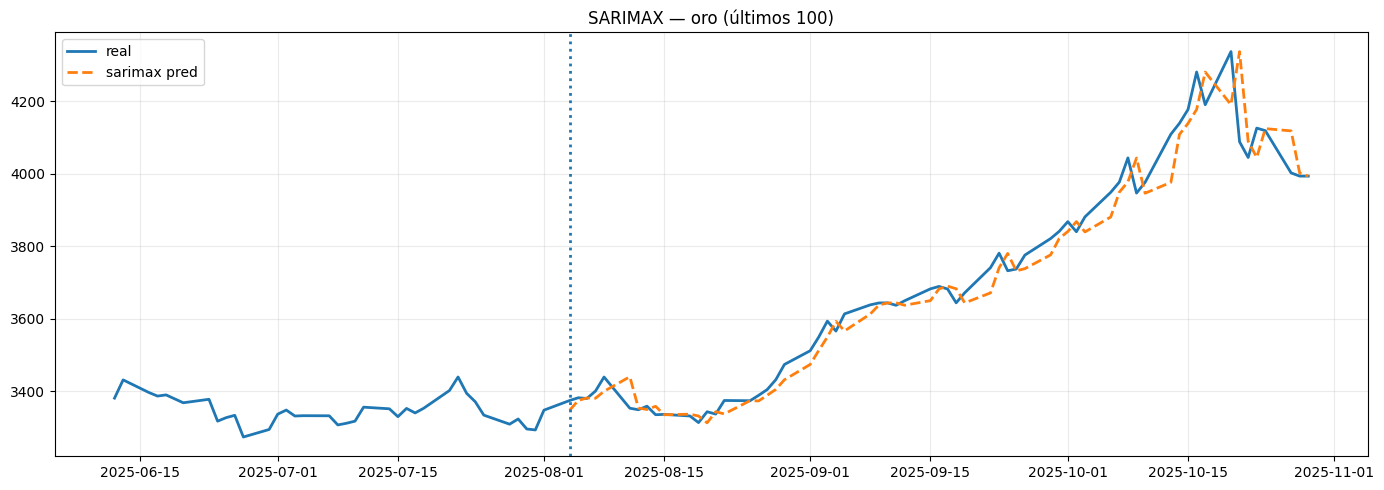

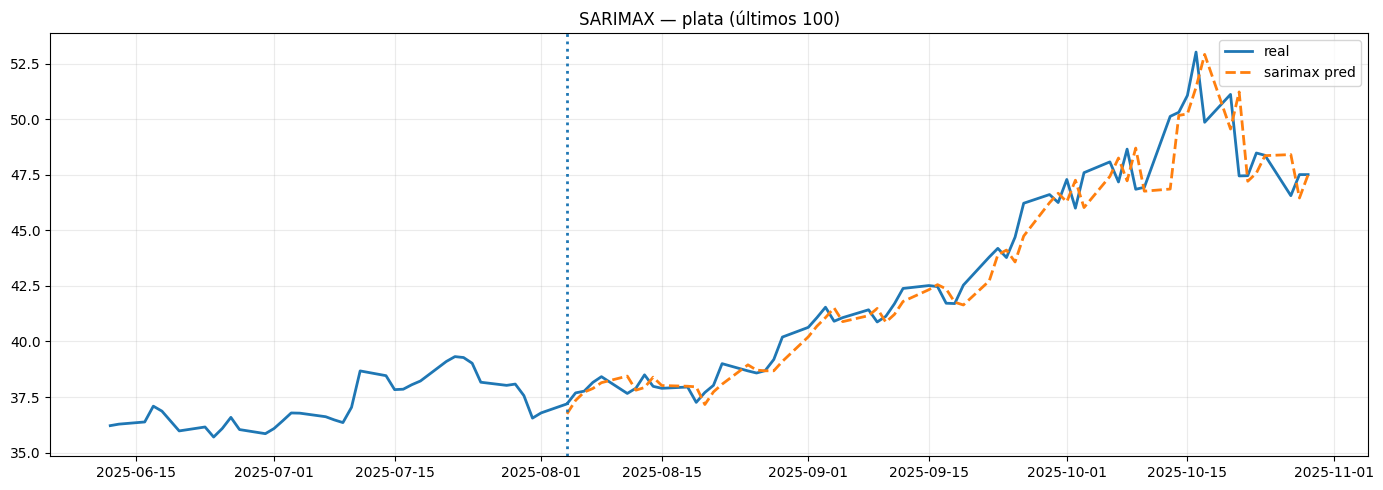

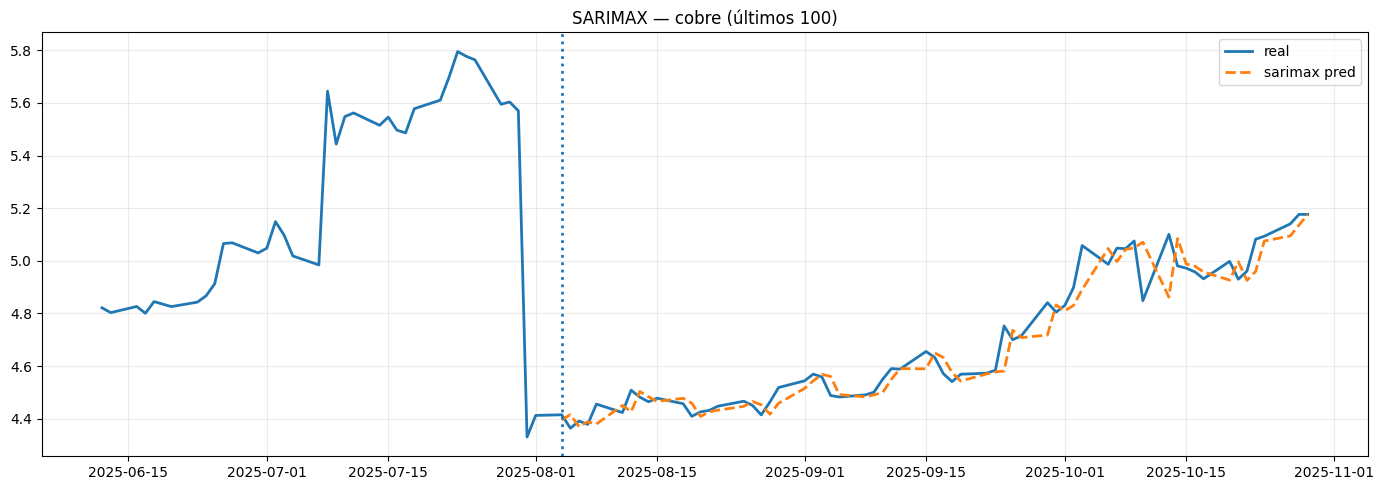

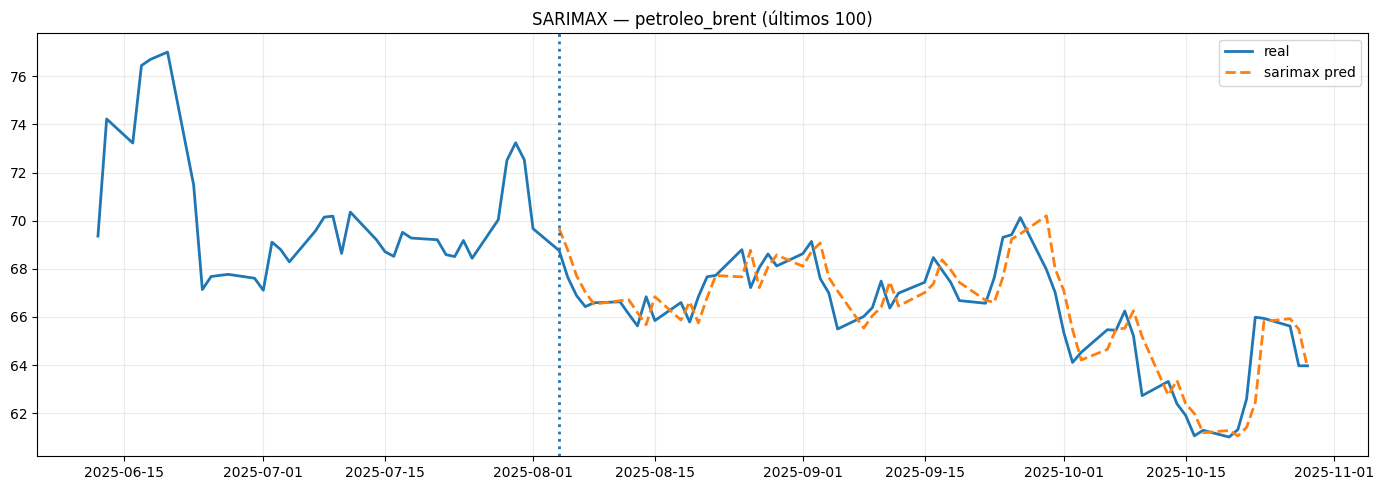

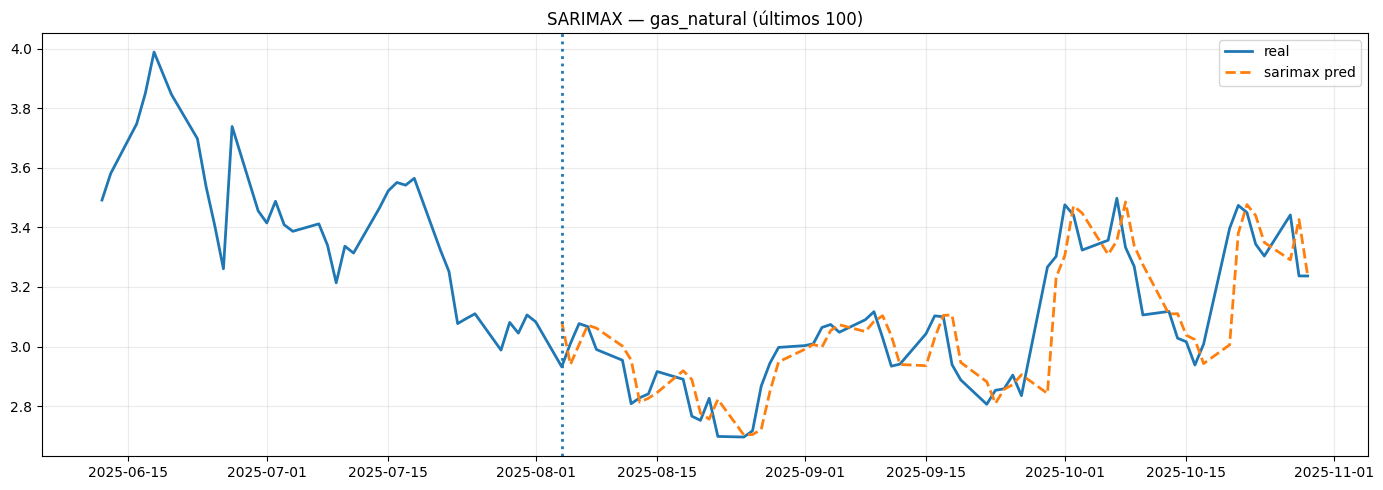

In [53]:
lista=["oro", "plata", "cobre", "petroleo_brent", "gas_natural"]

for i in lista:
    plot_sarimax_prediction(i, df_consol_train, df_consol_test, df_pred_test_all, n_last=100)

## LSTM: clases/funciones

In [ ]:
DEVICE = torch.device("cuda")

def set_seed_torch(seed: int = 42) -> None:
    set_seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

class MultiOutSeqDataset(Dataset):
    def __init__(self, X_seq: np.ndarray, Y_seq: np.ndarray):
        self.X = torch.tensor(X_seq, dtype=torch.float32)
        self.Y = torch.tensor(Y_seq, dtype=torch.float32)
    def __len__(self) -> int:
        return self.X.shape[0]
    def __getitem__(self, idx: int):
        return self.X[idx], self.Y[idx]

# =========================
# MODEL (bidirectional SIEMPRE False)
# =========================
class MultiOutLSTM(nn.Module):
    def __init__(self, input_dim: int, n_assets: int, horizon: int,
                 hidden_size: int = 128, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.drop = nn.Dropout(dropout)
        self.heads = nn.ModuleList([nn.Linear(hidden_size, horizon) for _ in range(n_assets)])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)              # (B,T,H)
        h = self.drop(out[:, -1, :])       # (B,H)
        yhat = torch.stack([head(h) for head in self.heads], dim=1)  # (B,A,Horizon)
        return yhat

# =========================
# ROLLING ORIGIN FOLDS
# =========================
def rolling_origin_folds(n: int, n_folds: int, val_size: int, min_train: int = 200) -> List[Tuple[int, int]]:
    folds = []
    for k in range(n_folds):
        val_end = n - (n_folds - 1 - k) * val_size
        val_start = val_end - val_size
        train_end = val_start
        if train_end >= min_train:
            folds.append((train_end, val_end))
    return folds

# =========================
# TRAIN 
# =========================
def train_model(X_seq: np.ndarray, Y_seq: np.ndarray, cfg: Dict, seed: int) -> MultiOutLSTM:
    set_seed(seed)

    model = MultiOutLSTM(
        input_dim=X_seq.shape[-1],
        n_assets=int(cfg["n_assets"]),
        horizon=int(cfg["horizon"]),
        hidden_size=int(cfg.get("hidden_size", 128)),
        num_layers=int(cfg.get("num_layers", 2)),
        dropout=float(cfg.get("dropout", 0.2)),
    ).to(DEVICE)

    # early-stop interno: último 10% de secuencias
    val_frac = float(cfg.get("internal_val_frac", 0.10))
    n = len(X_seq)
    n_val = max(1, int(n * val_frac)) if n > 30 else 0

    if n_val > 0:
        X_tr, Y_tr = X_seq[:-n_val], Y_seq[:-n_val]
        X_va, Y_va = X_seq[-n_val:], Y_seq[-n_val:]
    else:
        X_tr, Y_tr = X_seq, Y_seq
        X_va, Y_va = None, None

    bs = int(cfg.get("batch_size", 64))
    train_loader = DataLoader(MultiOutSeqDataset(X_tr, Y_tr), batch_size=bs, shuffle=True, num_workers=0)

    val_loader = None
    if X_va is not None:
        val_loader = DataLoader(MultiOutSeqDataset(X_va, Y_va), batch_size=bs, shuffle=False, num_workers=0)

    criterion = nn.MSELoss()
    opt = torch.optim.Adam(
        model.parameters(),
        lr=float(cfg.get("lr", 1e-3)),
        weight_decay=float(cfg.get("weight_decay", 0.0))
    )

    max_epochs = int(cfg.get("epochs", 30))
    patience = int(cfg.get("patience", 5))
    min_delta = float(cfg.get("min_delta", 1e-5))

    best_state = None
    best_val = float("inf")
    bad = 0

    for _ in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            yhat = model(xb)
            loss = criterion(yhat, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

        if val_loader is None:
            continue

        model.eval()
        with torch.no_grad():
            vals = []
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                yhat = model(xb)
                vals.append(criterion(yhat, yb).item())
            v = float(np.mean(vals)) if vals else float("inf")

        if v + min_delta < best_val:
            best_val = v
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

# =========================
# GRILLA 
# =========================
def build_param_grid_sampled_fast(n_samples=360, seed=42):
    rng = np.random.default_rng(seed)

    timesteps_list    = [5,10,20,30, 45, 60]
    hidden_size_list  = [96, 128]
    num_layers_list   = [2]
    dropout_list      = [0.15, 0.20]
    lr_list           = [1e-4, 3e-4, 5e-4, 1e-3, 1e-5]
    batch_size_list   = [32,64, 128]              
    weight_decay_list = [1e-4]

    # epochs/patience bajos 
    def epochs_for(L):   return 20 if L == 1 else (25 if L == 2 else 30)
    def patience_for(L): return 3  if L == 1 else (4  if L == 2 else 5)

    all_cfgs = []
    for T, H, L, D, LR, BS, WD in product(
        timesteps_list, hidden_size_list, num_layers_list, dropout_list,
        lr_list, batch_size_list, weight_decay_list
    ):
        if L == 3 and H < 96:
            continue

        all_cfgs.append({
            "timesteps": int(T),
            "hidden_size": int(H),
            "num_layers": int(L),
            "dropout": float(D),
            "lr": float(LR),
            "batch_size": int(BS),
            "weight_decay": float(WD),
            "epochs": int(epochs_for(L)),
            "patience": int(patience_for(L)),
            "internal_val_frac": 0.10,
        })

    space_size = len(all_cfgs)
    n_samples = min(int(n_samples), space_size)
    idx = rng.choice(space_size, size=n_samples, replace=False)
    sampled = [all_cfgs[i] for i in idx]
    return sampled, space_size  


# =========================
# SEQUENCES
# =========================
def create_sequences_multioutput(
    X_scaled: np.ndarray, Y_scaled: np.ndarray, timesteps: int, horizon: int
) -> Tuple[np.ndarray, np.ndarray]:
    N = len(X_scaled)
    last = N - timesteps - horizon
    X_seq, Y_seq = [], []
    for i in range(last + 1):
        X_seq.append(X_scaled[i:i+timesteps, :])               # (T,F)
        y_block = Y_scaled[i+timesteps:i+timesteps+horizon, :] # (H,A)
        Y_seq.append(y_block.T)                                # (A,H)
    return np.asarray(X_seq), np.asarray(Y_seq)

def make_forecast_input(X_scaled: np.ndarray, end_idx: int, timesteps: int) -> np.ndarray:
    s = end_idx - timesteps
    if s < 0:
        raise ValueError("No hay suficientes timesteps para armar la ventana.")
    return X_scaled[s:end_idx, :][None, :, :]  # (1,T,F)

# =========================
# BUILD X + RETURNS + PRICES (sin colisiones)
# =========================
def build_X_returns_prices(
    df: pd.DataFrame,
    target_cols: List[str],
    extra_feature_cols: Optional[List[str]] = None,
    include_target_returns_in_X: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    df = df.sort_index().copy()

    if df.columns.duplicated().any():
        dups = df.columns[df.columns.duplicated()].tolist()
        raise ValueError(f"Tu df de entrada ya trae columnas duplicadas: {dups}")

    df_prices = df[target_cols].astype(float)

    ret_cols = [f"{c}__ret" for c in target_cols]
    df_ret = pd.DataFrame(
        {f"{c}__ret": safe_log_returns(df_prices[c]) for c in target_cols},
        index=df.index
    )

    if extra_feature_cols is None:
        num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        extra_feature_cols = [c for c in num_cols if c not in target_cols]
    df_extra = df[extra_feature_cols].copy()

    # Nota: dropna sobre TODO (extra+prices+ret). Si pierdes demasiadas filas, hay que imputar exógenas.
    df_align = pd.concat([df_extra, df_prices, df_ret], axis=1).dropna(axis=0)

    df_prices_al = df_align[target_cols].astype(float)

    df_ret_al = df_align[ret_cols].astype(float).copy()
    df_ret_al.columns = target_cols

    if include_target_returns_in_X:
        df_X = pd.concat([df_ret_al.add_suffix("__ret_inX"), df_align[df_extra.columns]], axis=1)
    else:
        df_X = df_align[df_extra.columns]

    return df_X, df_ret_al, df_prices_al

def safe_log_returns(price: pd.Series) -> pd.Series:
    s = price.astype(float)
    if (s <= 0).any():
        raise ValueError("Hay precios <= 0. Log-return requiere precios positivos.")
    return np.log(s).diff() 

def returns_to_prices(last_price: float, log_returns: np.ndarray) -> np.ndarray:
    return last_price * np.exp(np.cumsum(log_returns))

# =========================
# GRID SEARCH (selección por CV MAPE en PRECIO) + PROGRESO
# =========================
def grid_search_multitarget_by_val_mape(
    df_train: pd.DataFrame,
    target_cols: List[str],
    param_grid: List[Dict],
    seeds: Tuple[int, ...],
    horizon: int,
    val_size: int,
    n_folds: int,
    include_target_returns_in_X: bool = True,
) -> pd.DataFrame:

    df_X, df_ret, df_prices = build_X_returns_prices(
        df_train, target_cols,
        extra_feature_cols=None,
        include_target_returns_in_X=include_target_returns_in_X
    )

    X_full = df_X.values.astype(float)
    R_full = df_ret.values.astype(float)
    P_full = df_prices.values.astype(float)

    n, n_assets = R_full.shape
    folds = rolling_origin_folds(n, n_folds=n_folds, val_size=val_size, min_train=max(200, 4*val_size + 2*horizon))
    if len(folds) == 0:
        raise ValueError("No hay suficientes datos (post-alineación) para CV rolling-origin.")

    rows = []
    t0 = time.time()

    for cfg_id, base in enumerate(param_grid):
        cfg = dict(base)
        cfg["horizon"] = int(horizon)
        cfg["n_assets"] = int(n_assets)
        timesteps = int(cfg.get("timesteps", 30))

        fold_mapes, fold_rmses = [], []

        for train_end, val_end in folds:
            X_scaler = StandardScaler().fit(X_full[:train_end, :])
            X_sc = X_scaler.transform(X_full[:val_end, :])

            y_scalers = []
            R_sc = np.zeros_like(R_full[:val_end, :], dtype=float)
            for j in range(n_assets):
                sc = StandardScaler().fit(R_full[:train_end, j].reshape(-1, 1))
                y_scalers.append(sc)
                R_sc[:, j] = sc.transform(R_full[:val_end, j].reshape(-1, 1)).reshape(-1)

            X_train_seq, Y_train_seq = create_sequences_multioutput(
                X_sc[:train_end, :], R_sc[:train_end, :], timesteps, horizon
            )
            if len(X_train_seq) < 30:
                continue

            x_in = make_forecast_input(X_sc, end_idx=train_end, timesteps=timesteps)
            x_in_t = torch.tensor(x_in, dtype=torch.float32, device=DEVICE)

            eval_H = min(horizon, val_size)
            true_prices = P_full[train_end:train_end+eval_H, :]

            seed_mape, seed_rmse = [], []
            for seed in seeds:
                model = train_model(X_train_seq, Y_train_seq, cfg, seed)
                model.eval()
                with torch.no_grad():
                    yhat_sc = model(x_in_t).detach().cpu().numpy().reshape(n_assets, horizon)  # (A,H)

                pred_prices = np.zeros((eval_H, n_assets), float)
                for j in range(n_assets):
                    mean = float(y_scalers[j].mean_[0])
                    scale = float(y_scalers[j].scale_[0])
                    yhat_ret = yhat_sc[j, :eval_H] * scale + mean
                    last_p = float(P_full[train_end - 1, j])
                    pred_prices[:, j] = returns_to_prices(last_p, yhat_ret)

                seed_rmse.append(float(np.mean([rmse(true_prices[:, j], pred_prices[:, j]) for j in range(n_assets)])))
                seed_mape.append(float(np.mean([mape(true_prices[:, j], pred_prices[:, j]) for j in range(n_assets)])))

            fold_rmses.append(float(np.mean(seed_rmse)))
            fold_mapes.append(float(np.mean(seed_mape)))

        cv_rmse = float(np.mean(fold_rmses)) if fold_rmses else float("inf")
        cv_mape = float(np.mean(fold_mapes)) if fold_mapes else float("inf")

        rows.append({
            "cfg_id": cfg_id,
            "cv_mape_price": cv_mape,
            "cv_rmse_price": cv_rmse,
            **cfg
        })

        # progreso + ETA
        done = cfg_id + 1
        total = len(param_grid)
        elapsed = time.time() - t0
        per_cfg = elapsed / done
        eta = per_cfg * (total - done)
        print(f"[{done}/{total}] cv_mape={cv_mape:.4f} | elapsed={elapsed/60:.1f}m | ETA={eta/60:.1f}m")

    return pd.DataFrame(rows).sort_values("cv_mape_price").reset_index(drop=True)


def evaluate_rolling_test_last_months(
    df_train_pretest: pd.DataFrame,
    df_test_3m: pd.DataFrame,
    target_cols: List[str],
    best_cfg: Dict,
    seeds: Tuple[int, ...],
    horizon: int,
    block_size: int,
    include_target_returns_in_X: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:

    df_total = pd.concat([df_train_pretest, df_test_3m]).sort_index()

    df_X, df_ret, df_prices = build_X_returns_prices(
        df_total, target_cols,
        extra_feature_cols=None,
        include_target_returns_in_X=include_target_returns_in_X
    )

    X_full = df_X.values.astype(float)
    R_full = df_ret.values.astype(float)
    P_full = df_prices.values.astype(float)
    idx = df_X.index

    n, n_assets = R_full.shape
    timesteps = int(best_cfg.get("timesteps", 30))
    H = int(horizon)
    step = int(block_size)

    test_start_date = df_test_3m.index.min()
    test_start_idx = int(idx.searchsorted(test_start_date))
    if test_start_idx <= 0:
        raise ValueError("test_start_idx inválido (<=0) luego de alinear por retornos.")

    # largo test (en índice alineado)
    test_len = len(idx[test_start_idx: idx.searchsorted(df_test_3m.index.max(), side="right")])
    test_len = int(max(1, test_len))

    actual = P_full[test_start_idx:test_start_idx + test_len, :]
    pred_mu = np.zeros_like(actual)
    pred_lo = np.zeros_like(actual)
    pred_hi = np.zeros_like(actual)

    pos = test_start_idx
    out_pos = 0

    while out_pos < test_len:
        train_end = pos
        remaining = test_len - out_pos
        eval_H = min(step, remaining)
        w_end = train_end + eval_H

        X_scaler = StandardScaler().fit(X_full[:train_end, :])
        X_sc = X_scaler.transform(X_full[:w_end, :])

        y_scalers = []
        for j in range(n_assets):
            sc = StandardScaler().fit(R_full[:train_end, j].reshape(-1, 1))
            y_scalers.append(sc)

        R_sc_train = np.zeros((train_end, n_assets), float)
        for j in range(n_assets):
            R_sc_train[:, j] = y_scalers[j].transform(R_full[:train_end, j].reshape(-1, 1)).reshape(-1)

        X_train_seq, Y_train_seq = create_sequences_multioutput(X_sc[:train_end, :], R_sc_train, timesteps, H)
        if len(X_train_seq) < 30:
            raise ValueError(f"Pocas secuencias en test rolling. Reduce timesteps. n_seq={len(X_train_seq)}")

        x_in = make_forecast_input(X_sc, end_idx=train_end, timesteps=timesteps)
        x_in_t = torch.tensor(x_in, dtype=torch.float32, device=DEVICE)

        seed_preds = []
        for seed in seeds:
            cfg = dict(best_cfg)
            cfg["horizon"] = H
            cfg["n_assets"] = n_assets

            model = train_model(X_train_seq, Y_train_seq, cfg, seed)
            model.eval()
            with torch.no_grad():
                yhat_sc_full = model(x_in_t).detach().cpu().numpy().reshape(n_assets, H)

            preds_prices = np.zeros((eval_H, n_assets), float)
            for j in range(n_assets):
                mean = float(y_scalers[j].mean_[0])
                scale = float(y_scalers[j].scale_[0])
                yhat_ret = yhat_sc_full[j, :eval_H] * scale + mean
                last_p = float(P_full[train_end - 1, j])
                preds_prices[:, j] = returns_to_prices(last_p, yhat_ret)

            seed_preds.append(preds_prices)

        seed_preds = np.stack(seed_preds, axis=0)  # (S, eval_H, A)
        mu = seed_preds.mean(axis=0)
        sd = seed_preds.std(axis=0, ddof=1) if seed_preds.shape[0] > 1 else np.zeros_like(mu)
        lo = mu - 1.96 * sd
        hi = mu + 1.96 * sd

        sl = slice(out_pos, out_pos + eval_H)
        pred_mu[sl, :] = mu
        pred_lo[sl, :] = lo
        pred_hi[sl, :] = hi

        pos += eval_H
        out_pos += eval_H

    test_dates = idx[test_start_idx:test_start_idx + test_len]
    data = {}
    for j, a in enumerate(target_cols):
        data[(a, "actual")] = actual[:, j]
        data[(a, "pred")]   = pred_mu[:, j]
        data[(a, "lo")]     = pred_lo[:, j]
        data[(a, "hi")]     = pred_hi[:, j]

    df_pred = pd.DataFrame(data, index=test_dates)
    df_pred.columns = pd.MultiIndex.from_tuples(df_pred.columns, names=["asset", "type"])

    rows = []
    rmses, mapes_ = [], []
    for a in target_cols:
        y_t = df_pred[(a, "actual")].values
        y_p = df_pred[(a, "pred")].values
        r = rmse(y_t, y_p)
        m = mape(y_t, y_p)
        rows.append({"asset": a, "rmse_price": r, "mape_price": m})
        rmses.append(r); mapes_.append(m)

    rows.append({"asset": "PROMEDIO", "rmse_price": float(np.mean(rmses)), "mape_price": float(np.mean(mapes_))})
    df_metrics = pd.DataFrame(rows)

    return df_pred, df_metrics 

def plot_lstm_prediction(df_pred: pd.DataFrame, asset: str, n_last: int = 120):
    if not isinstance(df_pred.columns, pd.MultiIndex):
        raise ValueError("df_pred debe tener columnas MultiIndex (asset,type).")

    s = df_pred.iloc[-n_last:].copy()
    y = s[(asset, "actual")].astype(float)
    yhat = s[(asset, "pred")].astype(float)
    lo = s[(asset, "lo")].astype(float)
    hi = s[(asset, "hi")].astype(float)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(s.index, y.values, linewidth=2, label="actual")
    ax.plot(s.index, yhat.values, linewidth=2, linestyle="--", label="lstm pred")
    ax.fill_between(s.index, lo.values, hi.values, alpha=0.2, label="CI (seeds)")

    ax.set_title(f"LSTM — {asset} (últimos {n_last})")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


## LSTM: implementación (entrenamiento + test rolling 3 meses)

In [61]:
target_cols = ["petroleo_brent", "oro", "cobre", "gas_natural", "plata"]


HORIZON = 10
BLOCK_SIZE = 10
VAL_SIZE = HORIZON

SEEDS_VAL  = (42,)            # para elegir HP (rápido)
SEEDS_TEST = (42, 333, 777)   # para robustez en test


param_grid, space_size = build_param_grid_sampled_fast(n_samples=10, seed=42)
print("Espacio total:", space_size, "| sample:", len(param_grid))

df_val_scores = grid_search_multitarget_by_val_mape(
    df_train=df_consol_train,
    target_cols=target_cols,
    param_grid=param_grid,
    seeds=SEEDS_VAL,
    horizon=HORIZON,
    val_size=VAL_SIZE,
    n_folds=5,
    include_target_returns_in_X=True
)

best_cfg = df_val_scores.iloc[0].to_dict()

print("BEST CONFIG:", {k: best_cfg[k] for k in [
    "timesteps","hidden_size","num_layers","dropout","lr","batch_size",
    "weight_decay","epochs","patience","internal_val_frac"
] if k in best_cfg})

display(df_val_scores.head(10))

df_pred_3m, df_metrics_3m = evaluate_rolling_test_last_months(
    df_train_pretest=df_consol_train,
    df_test_3m=df_consol_test,
    target_cols=target_cols,
    best_cfg=best_cfg,
    seeds=SEEDS_TEST,
    horizon=HORIZON,
    block_size=BLOCK_SIZE,
    include_target_returns_in_X=True
)

display(df_metrics_3m)
display(df_pred_3m.head(10))


Espacio total: 360 | sample: 10
[1/10] cv_mape=4.1155 | elapsed=0.5m | ETA=4.8m
[2/10] cv_mape=4.0804 | elapsed=0.8m | ETA=3.0m
[3/10] cv_mape=4.1204 | elapsed=1.1m | ETA=2.5m
[4/10] cv_mape=4.1337 | elapsed=1.4m | ETA=2.1m
[5/10] cv_mape=4.0759 | elapsed=1.5m | ETA=1.5m
[6/10] cv_mape=4.1791 | elapsed=1.7m | ETA=1.1m
[7/10] cv_mape=4.1076 | elapsed=1.8m | ETA=0.8m
[8/10] cv_mape=4.0861 | elapsed=2.0m | ETA=0.5m
[9/10] cv_mape=4.0842 | elapsed=2.8m | ETA=0.3m
[10/10] cv_mape=4.0974 | elapsed=2.9m | ETA=0.0m
BEST CONFIG: {'timesteps': 20.0, 'hidden_size': 128.0, 'num_layers': 2.0, 'dropout': 0.15, 'lr': 0.0003, 'batch_size': 128.0, 'weight_decay': 0.0001, 'epochs': 25.0, 'patience': 4.0, 'internal_val_frac': 0.1}


,cfg_id,cv_mape_price,cv_rmse_price,timesteps,hidden_size,num_layers,dropout,lr,batch_size,weight_decay,epochs,patience,internal_val_frac,horizon,n_assets
0,4,4.075941,10.076190,20,128,2,0.15,0.00030,128,0.0001,25,4,0.1,10,5
1,1,4.080399,9.913079,45,128,2,0.15,0.00010,128,0.0001,25,4,0.1,10,5
2,8,4.084182,9.624497,10,96,2,0.15,0.00001,32,0.0001,25,4,0.1,10,5
3,7,4.086132,9.870173,5,128,2,0.15,0.00030,32,0.0001,25,4,0.1,10,5
4,9,4.097421,10.057389,60,96,2,0.15,0.00030,128,0.0001,25,4,0.1,10,5
5,6,4.107607,9.506725,45,96,2,0.15,0.00100,32,0.0001,25,4,0.1,10,5
6,0,4.115524,10.236459,5,128,2,0.15,0.00010,32,0.0001,25,4,0.1,10,5
7,2,4.120357,9.944556,5,128,2,0.15,0.00010,64,0.0001,25,4,0.1,10,5
8,3,4.133715,10.411990,30,128,2,0.20,0.00050,32,0.0001,25,4,0.1,10,5
9,5,4.179054,10.466253,20,128,2,0.15,0.00030,32,0.0001,25,4,0.1,10,5


,asset,rmse_price,mape_price
0,petroleo_brent,2.844202,3.446489
1,oro,125.321546,2.580922
2,cobre,0.127753,1.901894
3,gas_natural,0.242629,5.756978
4,plata,1.775016,3.064256
5,PROMEDIO,26.062229,3.350108


asset      petroleo_brent                                           oro  \
type               actual       pred         lo         hi       actual   
FECHA                                                                     
2025-08-04      68.760002  69.775754  69.576888  69.974621  3374.399902   
2025-08-05      67.639999  69.877925  69.543059  70.212790  3381.899902   
2025-08-06      66.889999  69.913467  69.510498  70.316437  3380.000000   
2025-08-07      66.430000  69.917358  69.423901  70.410816  3400.300049   
2025-08-08      66.589996  69.910362  69.255125  70.565599  3439.100098   
2025-08-11      66.629997  69.956868  69.216009  70.697728  3353.100098   
2025-08-12      66.120003  70.061145  69.105597  71.016692  3348.899902   
2025-08-13      65.629997  70.149162  69.173400  71.124924  3358.699951   
2025-08-14      66.839996  70.230489  69.332767  71.128212  3335.199951   
2025-08-15      65.849998  70.373431  69.487801  71.259061  3336.000000   

asset                                               cobre                      \
type               pred           lo           hi  actual      pred        lo   
FECHA                                                                           
2025-08-04  3347.107015  3345.736188  3348.477842  4.4150  4.409616  4.406130   
2025-08-05  3347.350179  3346.060938  3348.639420  4.3640  4.408945  4.405469   
2025-08-06  3346.454753  3343.691262  3349.218243  4.3910  4.407547  4.399948   
2025-08-07  3345.818034  3343.190459  3348.445609  4.3785  4.406051  4.392866   
2025-08-08  3345.773600  3340.518861  3351.028340  4.4555  4.403236  4.392200   
2025-08-11  3346.338867  3340.472492  3352.205243  4.4235  4.400663  4.394982   
2025-08-12  3344.381673  3336.875442  3351.887904  4.5085  4.400321  4.394046   
2025-08-13  3343.851562  3336.605863  3351.097262  4.4820  4.398875  4.392321   
2025-08-14  3343.537191  3338.856963  3348.217419  4.4645  4.397811  4.395749   
2025-08-15  3342.819743  3333.178156  3352.461329  4.4780  4.396840  4.390189   

asset                gas_natural                                    plata  \
type              hi      actual      pred        lo        hi     actual   
FECHA                                                                       
2025-08-04  4.413103       2.932  3.082671  3.077210  3.088133  37.192001   
2025-08-05  4.412421       3.010  3.084167  3.066033  3.102300  37.687000   
2025-08-06  4.415145       3.077  3.090615  3.070965  3.110266  37.765999   
2025-08-07  4.419235       3.067  3.097279  3.069636  3.124922  38.158001   
2025-08-08  4.414272       2.990  3.098891  3.066785  3.130996  38.417000   
2025-08-11  4.406344       2.954  3.100617  3.061723  3.139511  37.661999   
2025-08-12  4.406596       2.808  3.106751  3.062961  3.150542  37.898998   
2025-08-13  4.405429       2.828  3.107179  3.058448  3.155910  38.499001   
2025-08-14  4.399873       2.841  3.111976  3.054107  3.169845  37.981998   
2025-08-15  4.403492       2.916  3.107797  3.037993  3.177601  37.894001   

asset                                        
type             pred         lo         hi  
FECHA                                        
2025-08-04  36.806870  36.766640  36.847099  
2025-08-05  36.816021  36.706010  36.926032  
2025-08-06  36.769229  36.662608  36.875849  
2025-08-07  36.772756  36.662687  36.882825  
2025-08-08  36.764002  36.651027  36.876978  
2025-08-11  36.764505  36.636899  36.892110  
2025-08-12  36.758457  36.622481  36.894433  
2025-08-13  36.736960  36.596170  36.877751  
2025-08-14  36.699771  36.576710  36.822831  
2025-08-15  36.684043  36.539295  36.828790

In [63]:
df_pred_3m

asset      petroleo_brent                                           oro  \
type               actual       pred         lo         hi       actual   
FECHA                                                                     
2025-08-04      68.760002  69.775754  69.576888  69.974621  3374.399902   
2025-08-05      67.639999  69.877925  69.543059  70.212790  3381.899902   
2025-08-06      66.889999  69.913467  69.510498  70.316437  3380.000000   
2025-08-07      66.430000  69.917358  69.423901  70.410816  3400.300049   
2025-08-08      66.589996  69.910362  69.255125  70.565599  3439.100098   
...                   ...        ...        ...        ...          ...   
2025-10-23      65.989998  63.072821  62.683639  63.462003  4125.500000   
2025-10-24      65.940002  63.174647  62.730167  63.619127  4118.399902   
2025-10-27      65.620003  65.954084  65.891288  66.016880  4001.899902   
2025-10-28      63.970001  65.986089  65.942534  66.029644  3993.100098   
2025-10-29      63.970001  66.000183  65.952851  66.047515  3993.100098   

asset                                               cobre                      \
type               pred           lo           hi  actual      pred        lo   
FECHA                                                                           
2025-08-04  3347.107015  3345.736188  3348.477842  4.4150  4.409616  4.406130   
2025-08-05  3347.350179  3346.060938  3348.639420  4.3640  4.408945  4.405469   
2025-08-06  3346.454753  3343.691262  3349.218243  4.3910  4.407547  4.399948   
2025-08-07  3345.818034  3343.190459  3348.445609  4.3785  4.406051  4.392866   
2025-08-08  3345.773600  3340.518861  3351.028340  4.4555  4.403236  4.392200   
...                 ...          ...          ...     ...       ...       ...   
2025-10-23  3982.466064  3948.553805  4016.378324  5.0820  4.857370  4.825865   
2025-10-24  3980.300618  3948.283072  4012.318165  5.0935  4.857259  4.821021   
2025-10-27  4116.290853  4110.192150  4122.389556  5.1405  5.092266  5.088193   
2025-10-28  4116.265137  4109.568820  4122.961454  5.1765  5.093445  5.081126   
2025-10-29  4116.768229  4108.178585  4125.357874  5.1765  5.089273  5.076597   

asset                gas_natural                                    plata  \
type              hi      actual      pred        lo        hi     actual   
FECHA                                                                       
2025-08-04  4.413103       2.932  3.082671  3.077210  3.088133  37.192001   
2025-08-05  4.412421       3.010  3.084167  3.066033  3.102300  37.687000   
2025-08-06  4.415145       3.077  3.090615  3.070965  3.110266  37.765999   
2025-08-07  4.419235       3.067  3.097279  3.069636  3.124922  38.158001   
2025-08-08  4.414272       2.990  3.098891  3.066785  3.130996  38.417000   
...              ...         ...       ...       ...       ...        ...   
2025-10-23  4.888875       3.344  3.114391  3.102141  3.126640  48.481998   
2025-10-24  4.893497       3.304  3.113549  3.099606  3.127492  48.376999   
2025-10-27  5.096340       3.442  3.300363  3.289435  3.311291  46.562000   
2025-10-28  5.105764       3.237  3.298381  3.279618  3.317143  47.509998   
2025-10-29  5.101949       3.237  3.292547  3.275283  3.309810  47.509998   

asset                                        
type             pred         lo         hi  
FECHA                                        
2025-08-04  36.806870  36.766640  36.847099  
2025-08-05  36.816021  36.706010  36.926032  
2025-08-06  36.769229  36.662608  36.875849  
2025-08-07  36.772756  36.662687  36.882825  
2025-08-08  36.764002  36.651027  36.876978  
...               ...        ...        ...  
2025-10-23  46.909761  46.591254  47.228267  
2025-10-24  46.912922  46.558879  47.266965  
2025-10-27  48.371663  48.245366  48.497961  
2025-10-28  48.369334  48.152630  48.586037  
2025-10-29  48.345104  48.056432  48.633776  

[63 rows x 20 columns]

## LSTM: gráfica de predicción

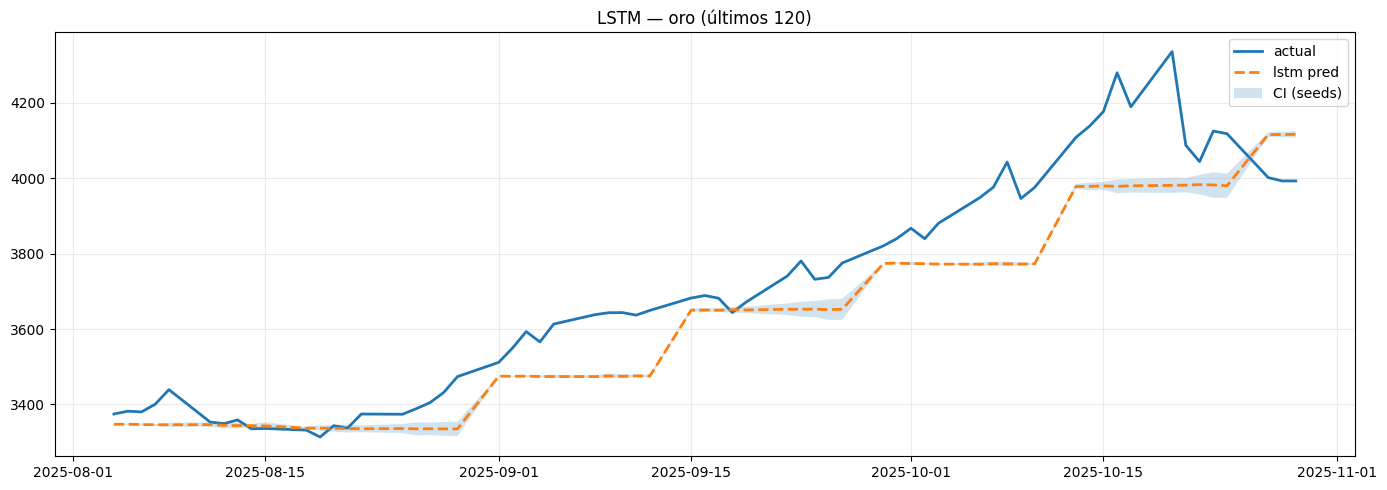

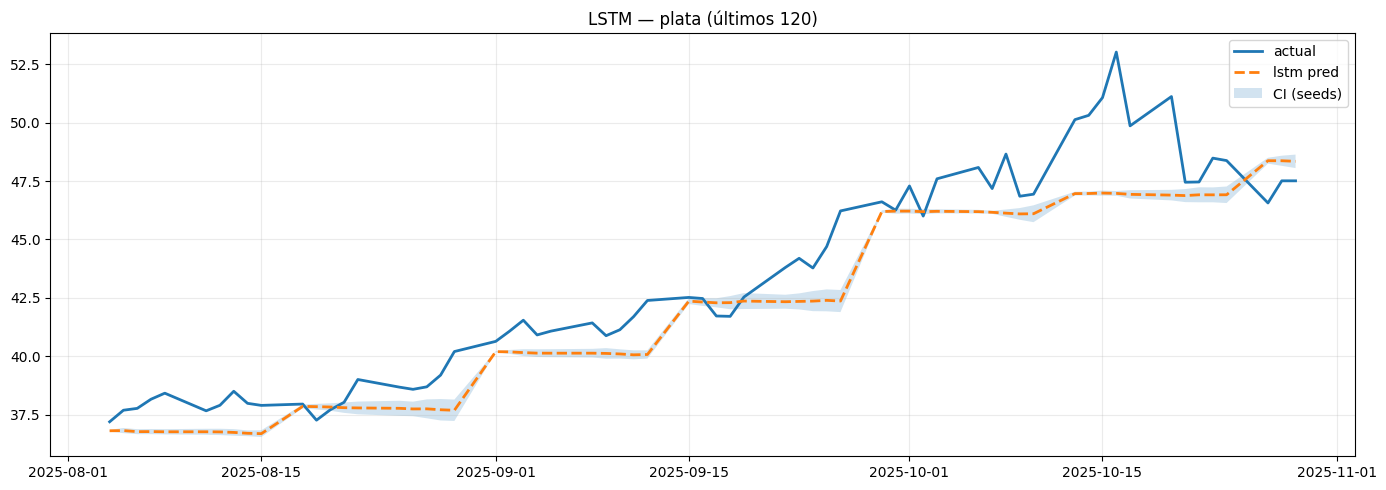

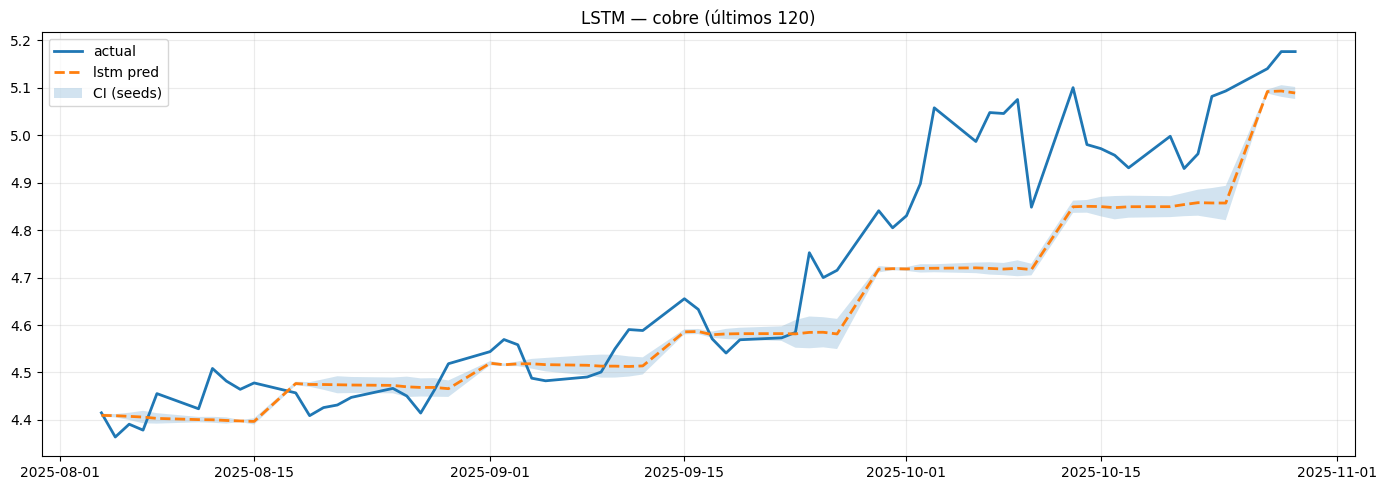

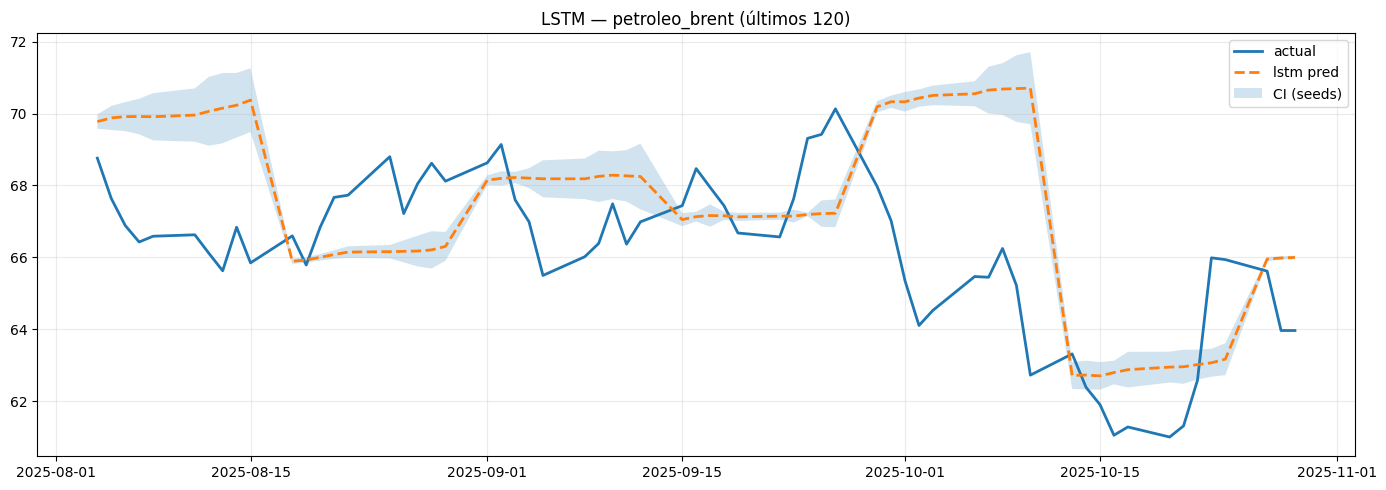

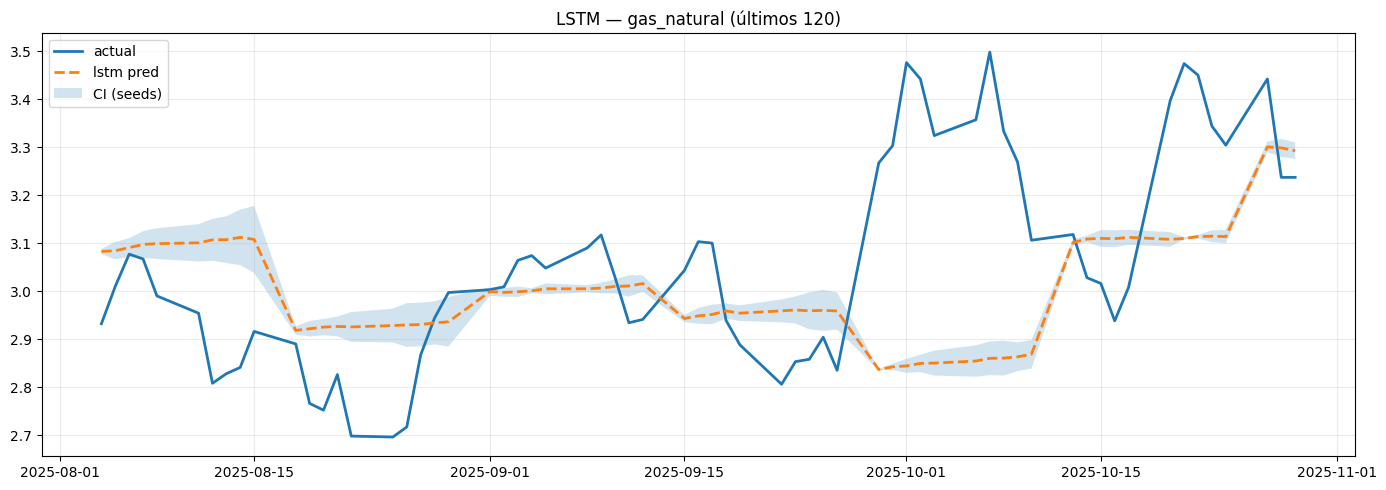

In [69]:
for i in lista:
    plot_lstm_prediction(df_pred_3m, i)